In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

color_list = ['#0072b2', '#d55e00', '#009e73','#f0e442',
              '#cc79a7', '#e69f00', '#56b4e9', '#000000']

In [3]:
def data_PDF(data, nbins=0):
    last_non_zero = np.nonzero(data)[0]
    nmax = last_non_zero[-1]
    if nbins == 0:
        nbins = freedman_diaconis_log_bins(data[:nmax])
        if nbins > len(data):
            nbins = len(data) -1
    if nbins > 300:
        nbins = 300
    mean = np.sum(data * np.arange(len(data)))/np.sum(data)
    bins, histo = new_logbins(data[:nmax], nbins) #Transforme les bins lin en bins log
    bin_center = (bins[1:] + bins[:-1])/2
    
    mask = histo != 0
    f_histo = histo[mask]
    f_bin_center = bin_center[mask]
    
    return f_histo, f_bin_center, nmax, mean, nbins

#   Size histogram as function of the distance to the boundary

#   For one simulation

In [28]:
folder = "/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp1n7"
params = read_parameters(folder)
L1 = params[0]
L2 = params[1]
nu = params[2]
data = np.loadtxt("{}/stat_pos_histosize.txt".format(folder), comments = "#").T

nb_ava = np.sum(data)
print(nb_ava)

300000000000.0


In [5]:
print(np.shape(data))
print(data[0])

(128, 65537)
[0.0000e+00 1.7364e+04 1.3125e+04 ... 0.0000e+00 0.0000e+00 1.0000e+00]


/tmp/ipykernel_1119034/3040446478.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


0.9840068099524911
0.9900737359536151
0.9979305368300403
0.9970287802579363
0.982638785564685
0.9421287307984921
0.933824464458934
0.9367801427398224
0.9544115879693117
0.9777764321147867
0.9828729899257405
0.9924572325663021
0.9976279992171432
0.9963912347051727
0.9977260551094768
0.9970074894530696
0.9983368760239474
0.9979264445086611
0.9983340542137266
0.9988340660420378
0.9958654641792751
0.9963364511735203
0.9969206518785309
0.9962514251643801
0.9967490233200628
0.9949235090253186
0.9962827189586079
0.9962690264390857
0.9953313590950491
0.9947097206093716
0.9965900986678601
0.9936253894842392
0.9947225903540142
0.9914253585754803
0.9949487932137905
0.992674760060878
0.9954726120756725
0.9937714397055178
0.9921872260217225
0.9961052937599045
0.994628020733506
0.9956234140641408
0.997069528959321
0.9905101817957025
0.9899420773835832
0.990264968962236
0.9955862757936548
0.9930706096932287
0.9935932512546951
0.9932654270954142
0.9922957136127949
0.9872000258639924
0.9949095706827653

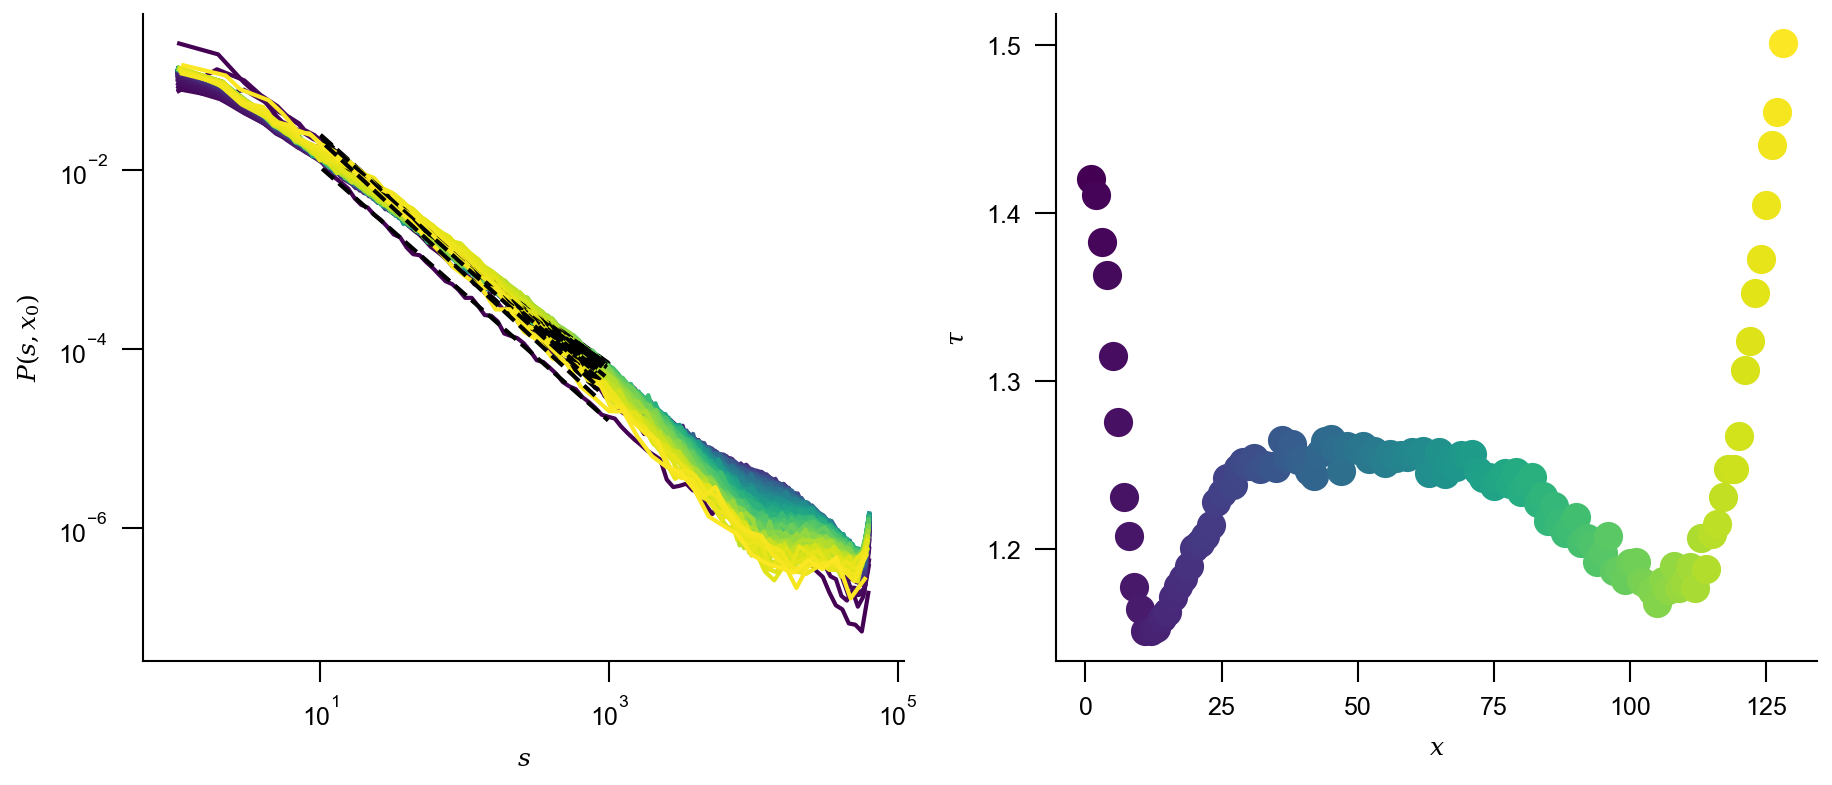

In [6]:
NCURVES = len(data)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax,ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    for i, line in enumerate(data):
        histo_s, bins_s, nonzero_s, mean_s,nbins_s = data_PDF(line)
        Txfit_s, Tyfit_s, Ttau_s, Tperr_s = PDF_fitting([histo_s], [bins_s], [10], [1100], [nu])
        if (-1<i<100000): 
            ax.plot(bins_s,histo_s, color = colors[i])
            ax.plot(Txfit_s[0],Tyfit_s[0], c = 'k', ls = '--')
        ax2.scatter(i+1, -Ttau_s[0], color = colors[i])
        
        
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$s$')
    ax.set_ylabel(r'$P(s,x_0)$')
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$\tau$')
    
plt.show()

##  Size 1

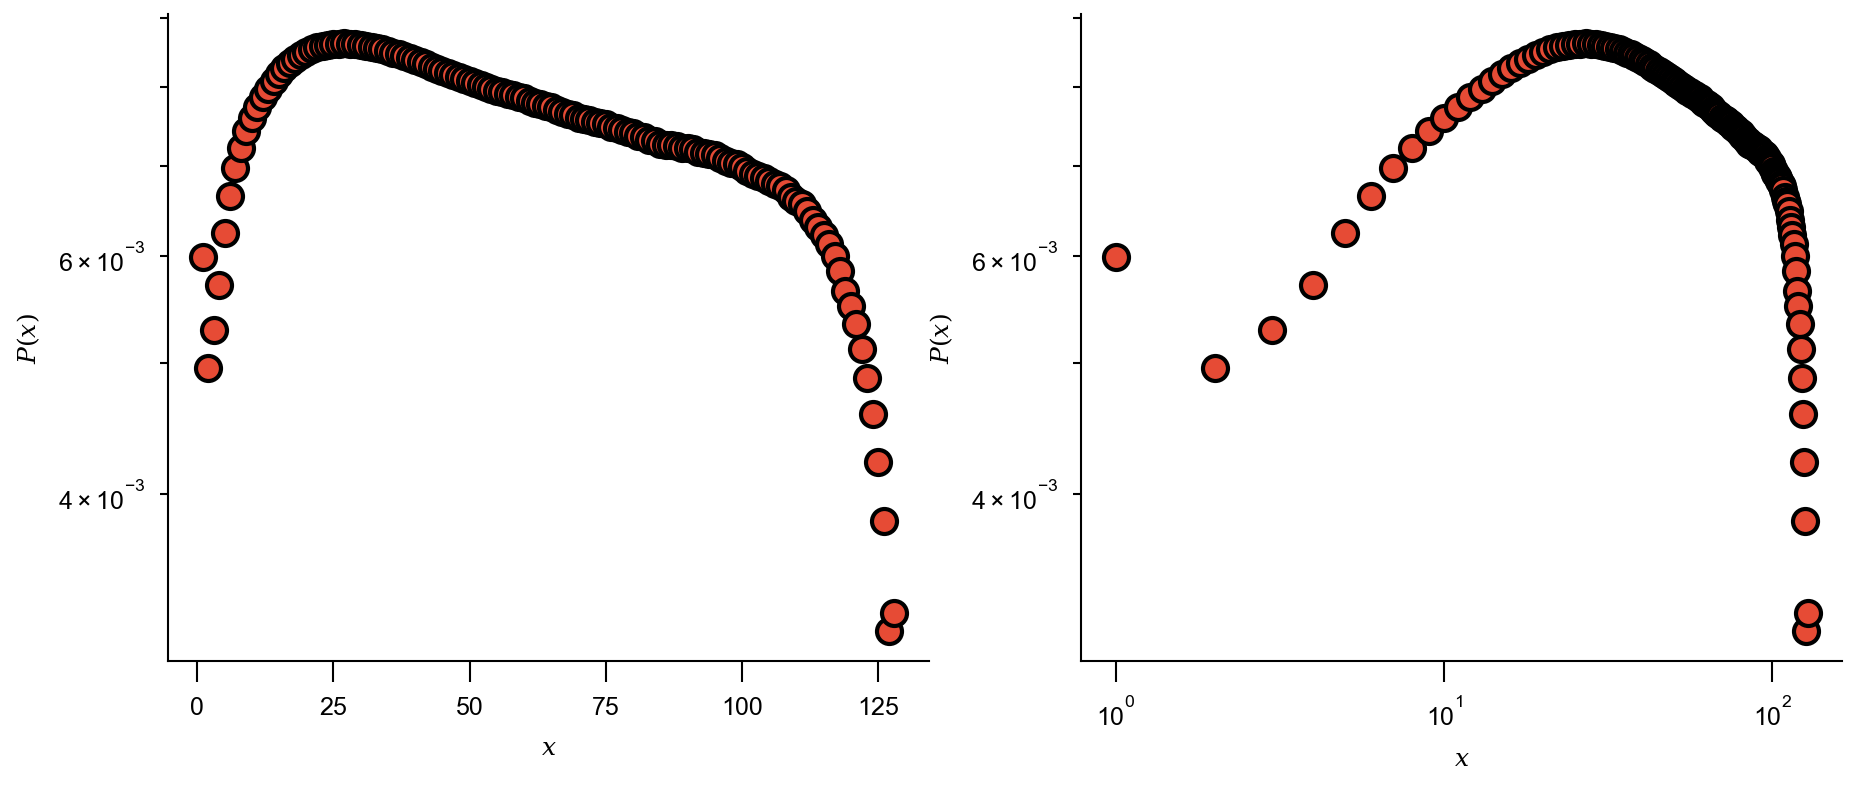

In [58]:
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    ax1.scatter(np.arange(1, L1+1), data[:,1]/nb_ava)
    ax2.scatter(np.arange(1, L1+1), data[:,1]/nb_ava)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
plt.show()

## All size

In [59]:
sum_histo = np.sum(data, axis = 1)

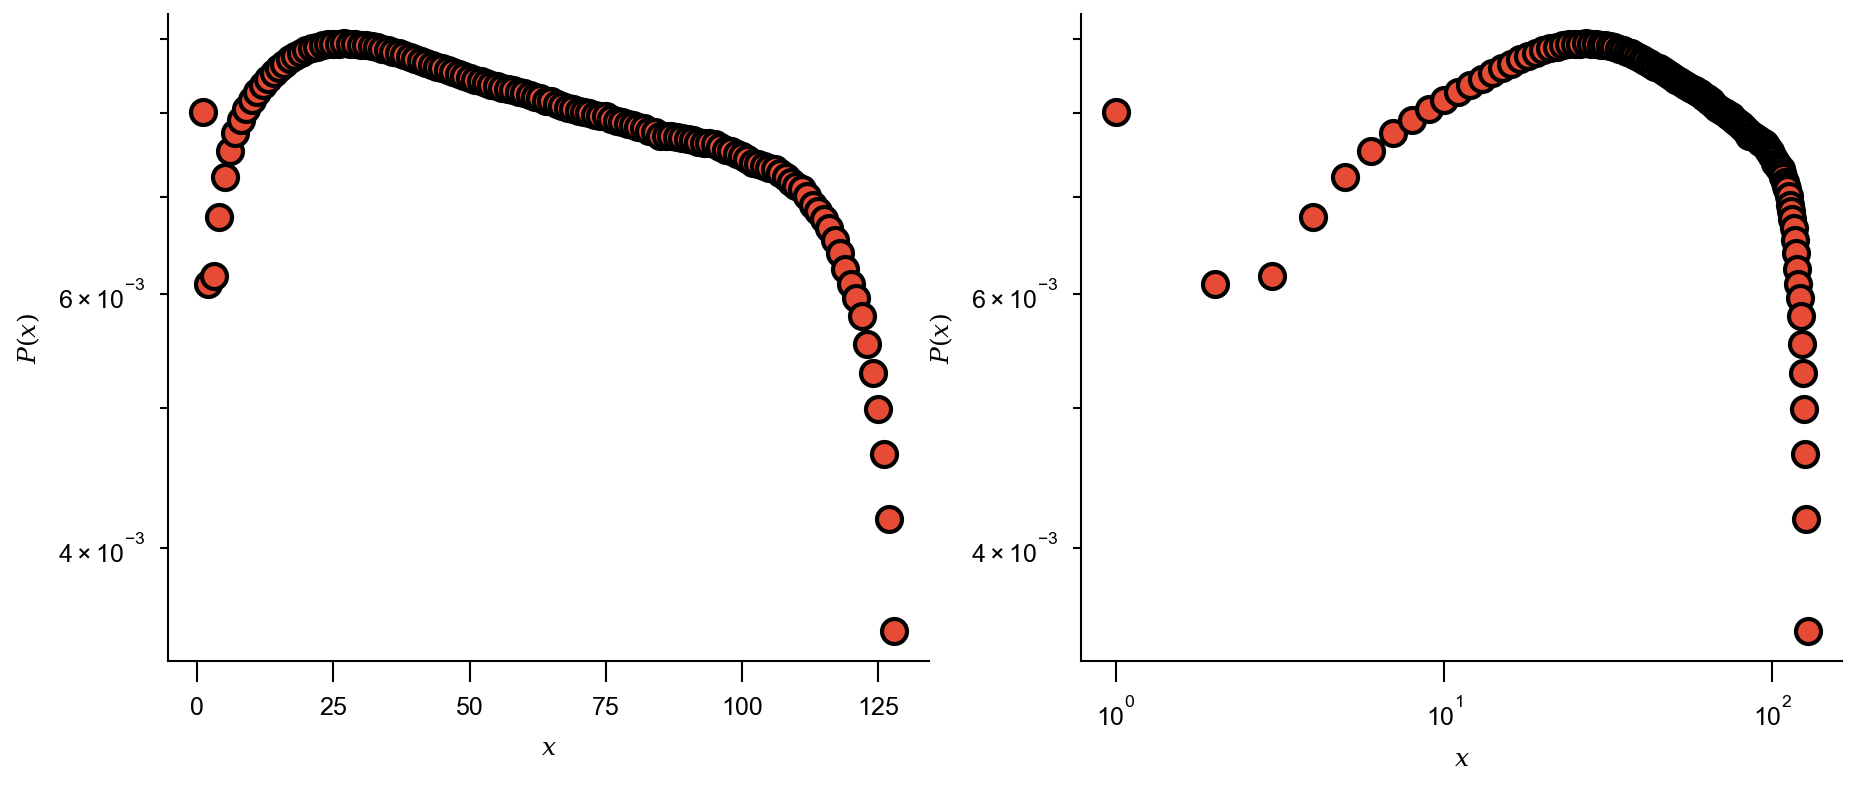

In [60]:
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    ax1.scatter(np.arange(1, L1+1), sum_histo/nb_ava)
    ax2.scatter(np.arange(1, L1+1), sum_histo/nb_ava)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
plt.show()

## More than 2

In [29]:
smin = 2
smax = int(len(data[0])/5)
sup2_histo = data[:, smin:smax]

In [30]:
sum_sup2_ava = np.sum(sup2_histo, axis = 1)

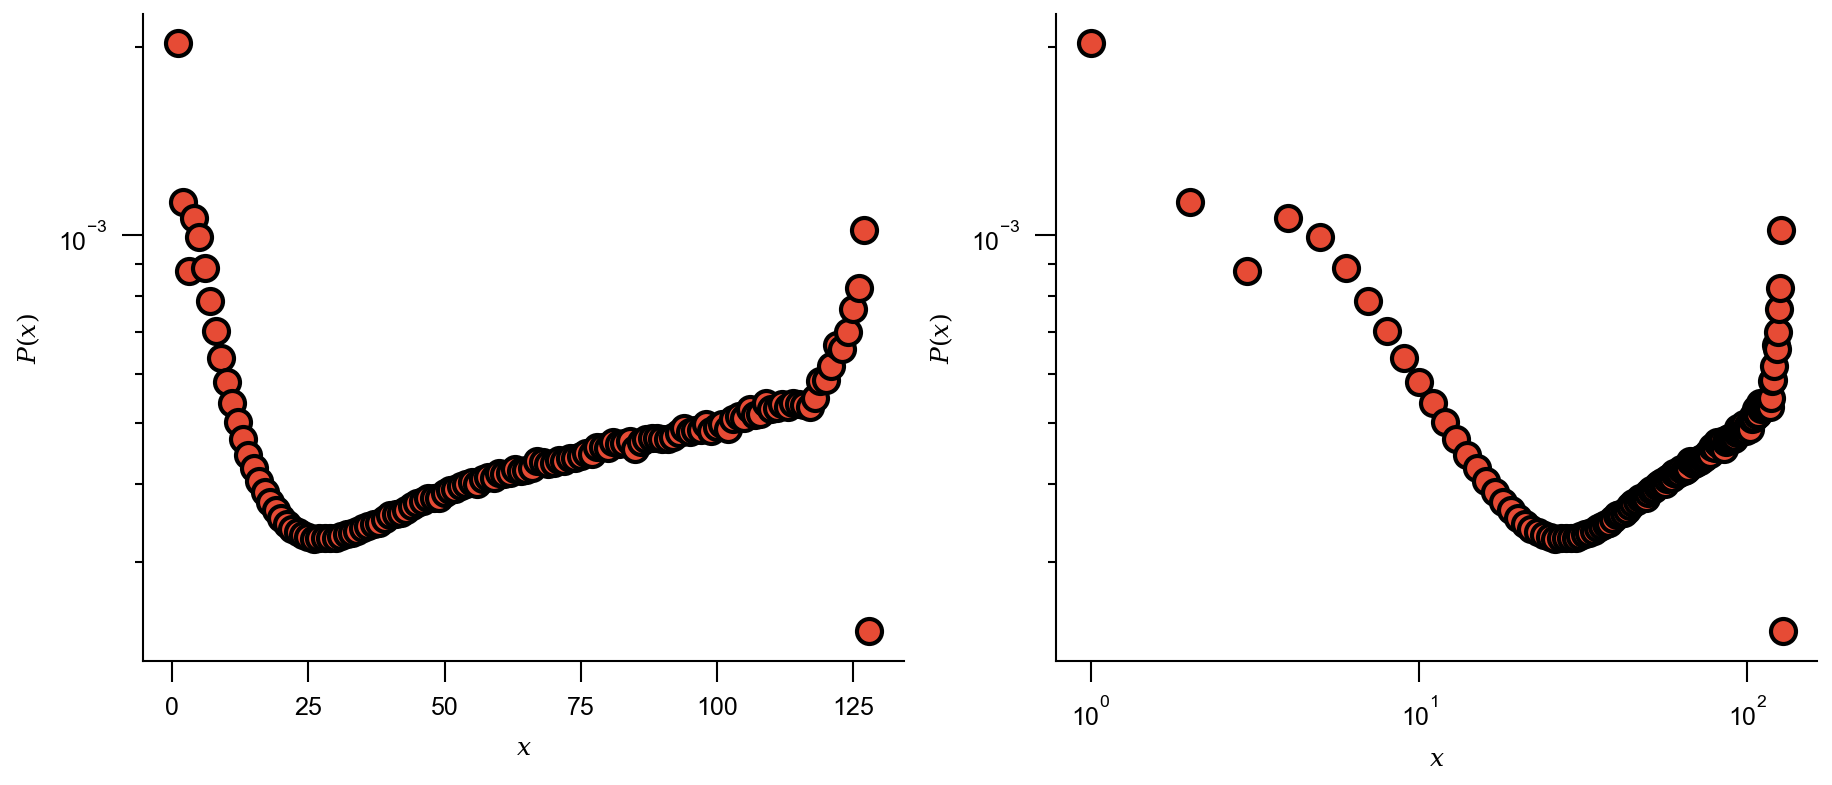

In [31]:
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    ax1.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava)
    ax2.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
plt.show()

##  More than n

In [64]:
smin = int(len(data[0])/20)
smax = int(len(data[0]))
large_ava_histo = data[:, smin:smax]

In [65]:
sum_large_ava = np.sum(large_ava_histo, axis = 1)

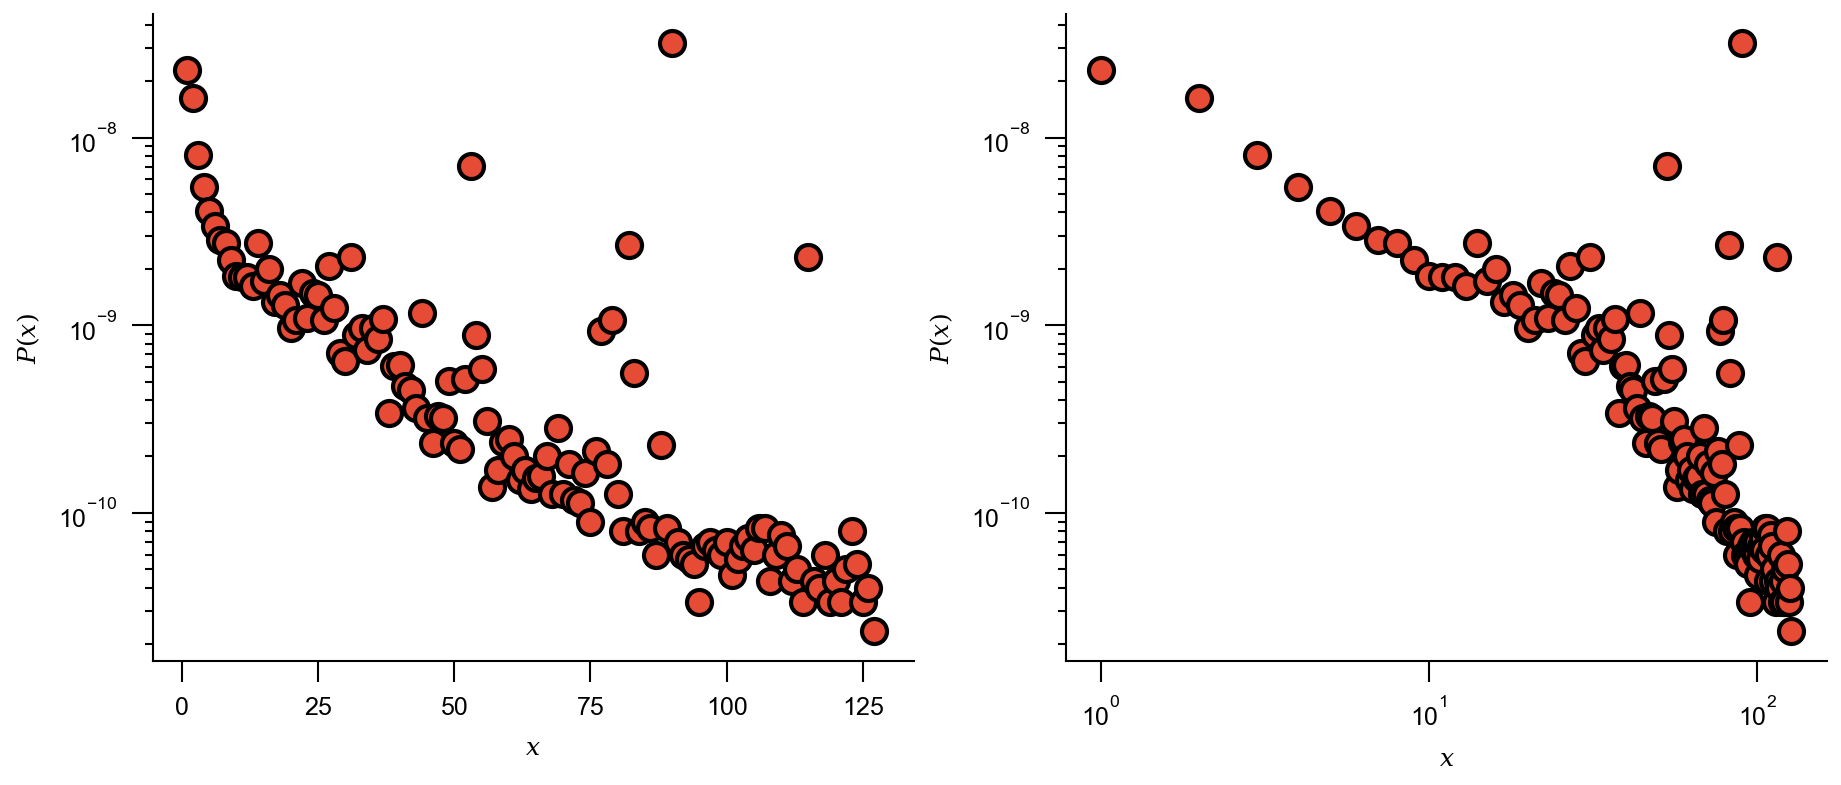

In [66]:
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    ax1.scatter(np.arange(1, L1+1), sum_large_ava/nb_ava)
    ax2.scatter(np.arange(1, L1+1), sum_large_ava/nb_ava)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
plt.show()

## Number as function of the distance for different region

###  2<s<10

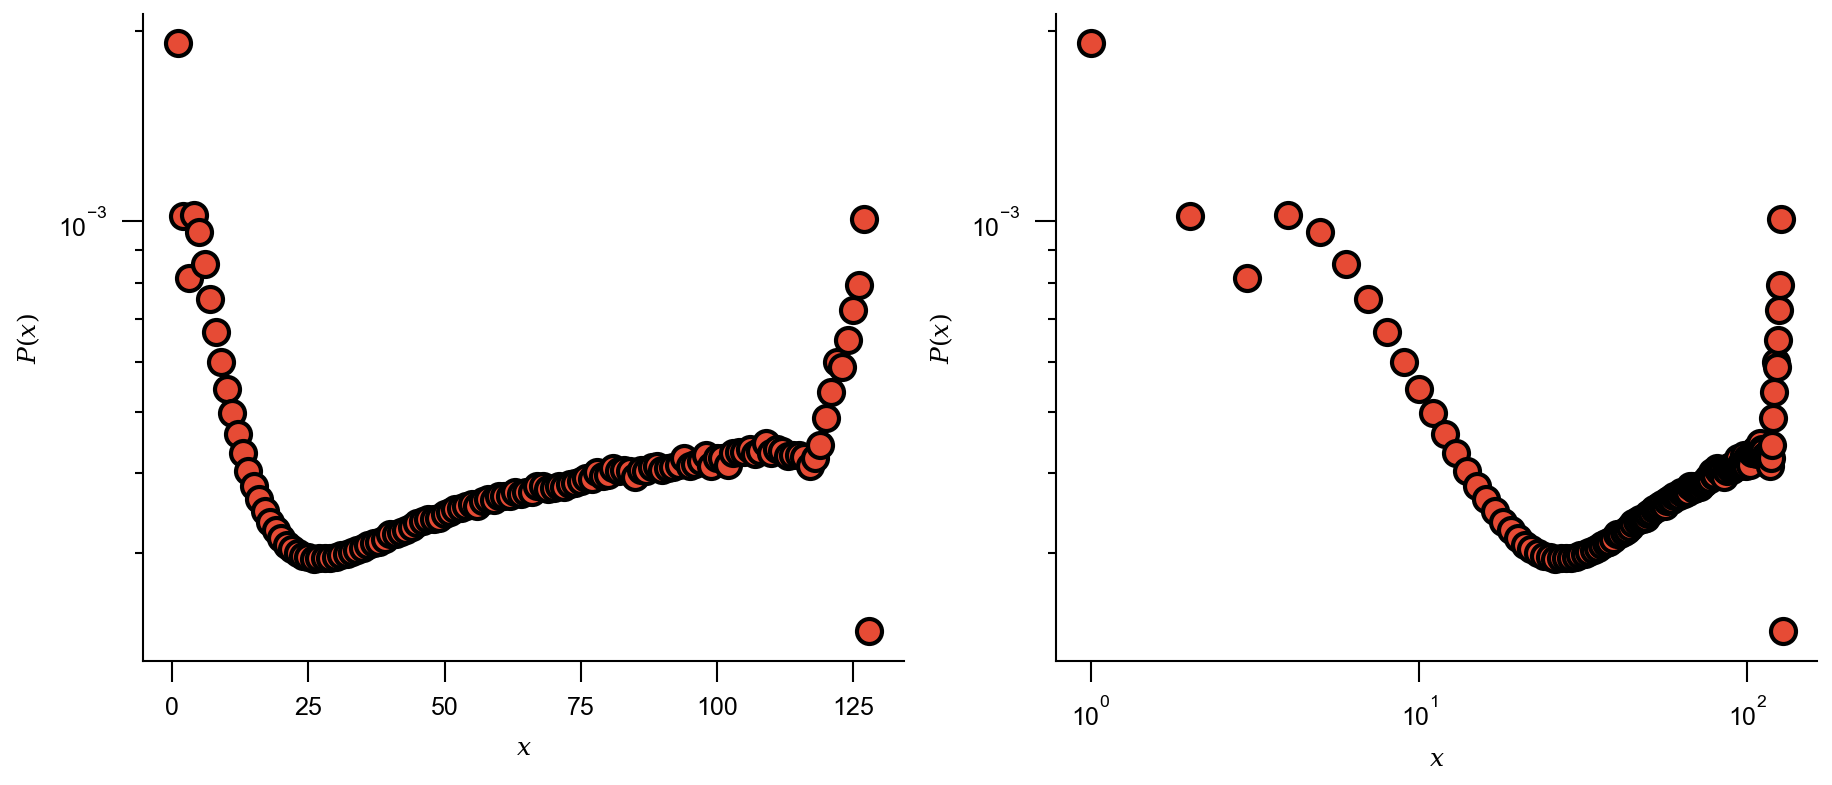

In [67]:
smin = 2
smax = 10
test_histo = data[:, smin:smax]
sum_test = np.sum(test_histo, axis = 1)
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    ax1.scatter(np.arange(1, L1+1), sum_test/nb_ava)
    ax2.scatter(np.arange(1, L1+1), sum_test/nb_ava)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
plt.show()

### 10<s<100

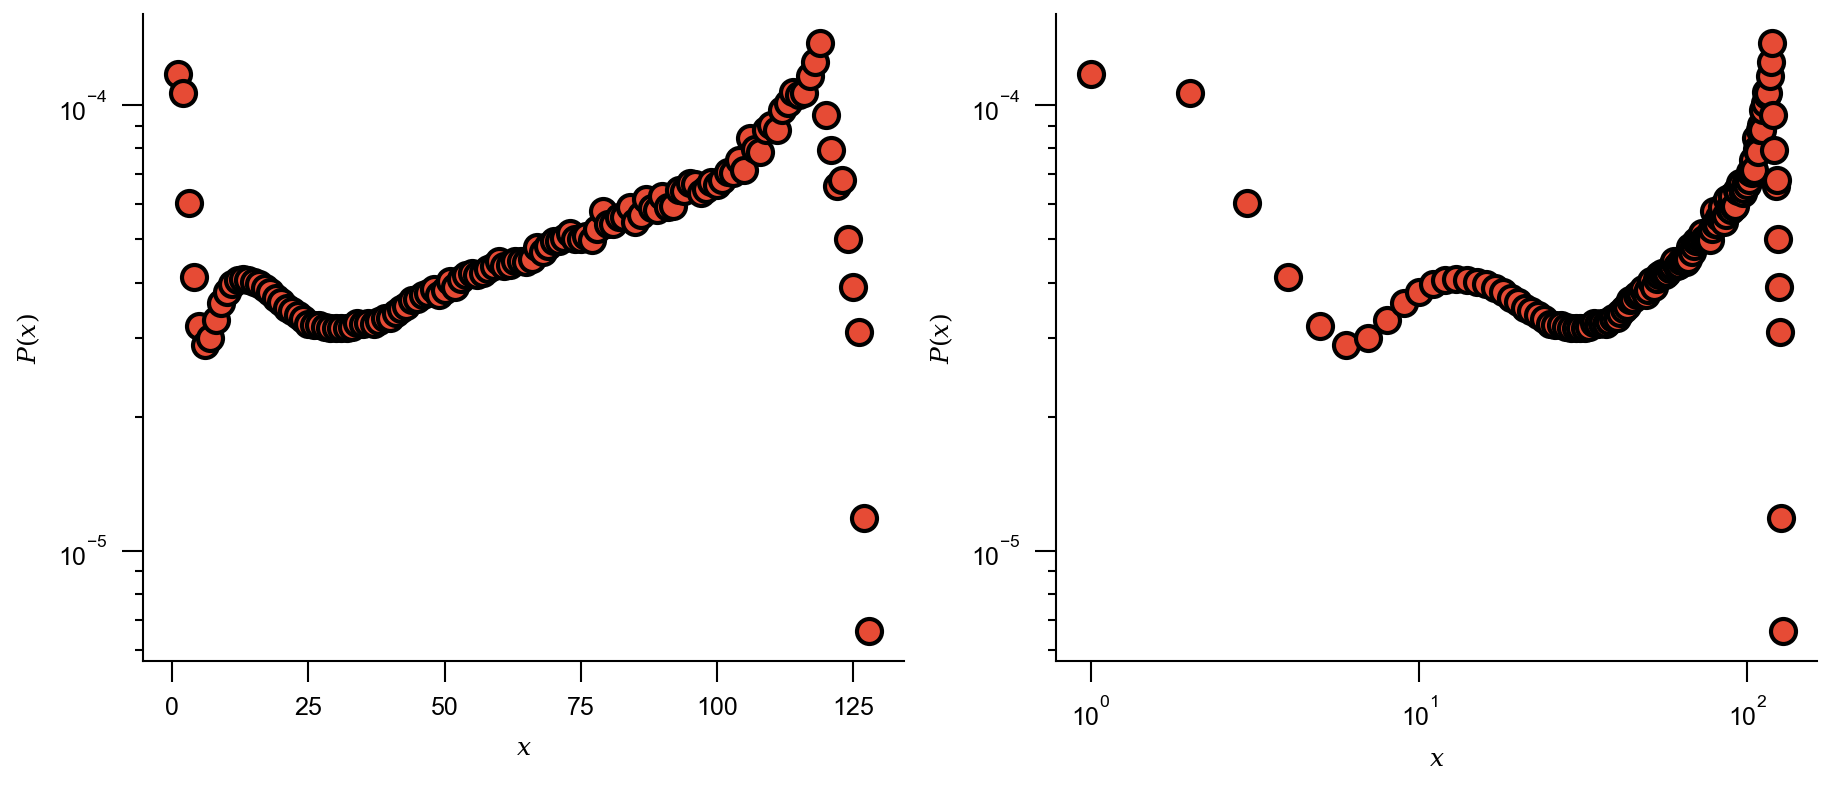

In [68]:
smin = 10
smax = 100
test_histo = data[:, smin:smax]
sum_test = np.sum(test_histo, axis = 1)
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    ax1.scatter(np.arange(1, L1+1), sum_test/nb_ava)
    ax2.scatter(np.arange(1, L1+1), sum_test/nb_ava)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
plt.show()

### 100<s<1000

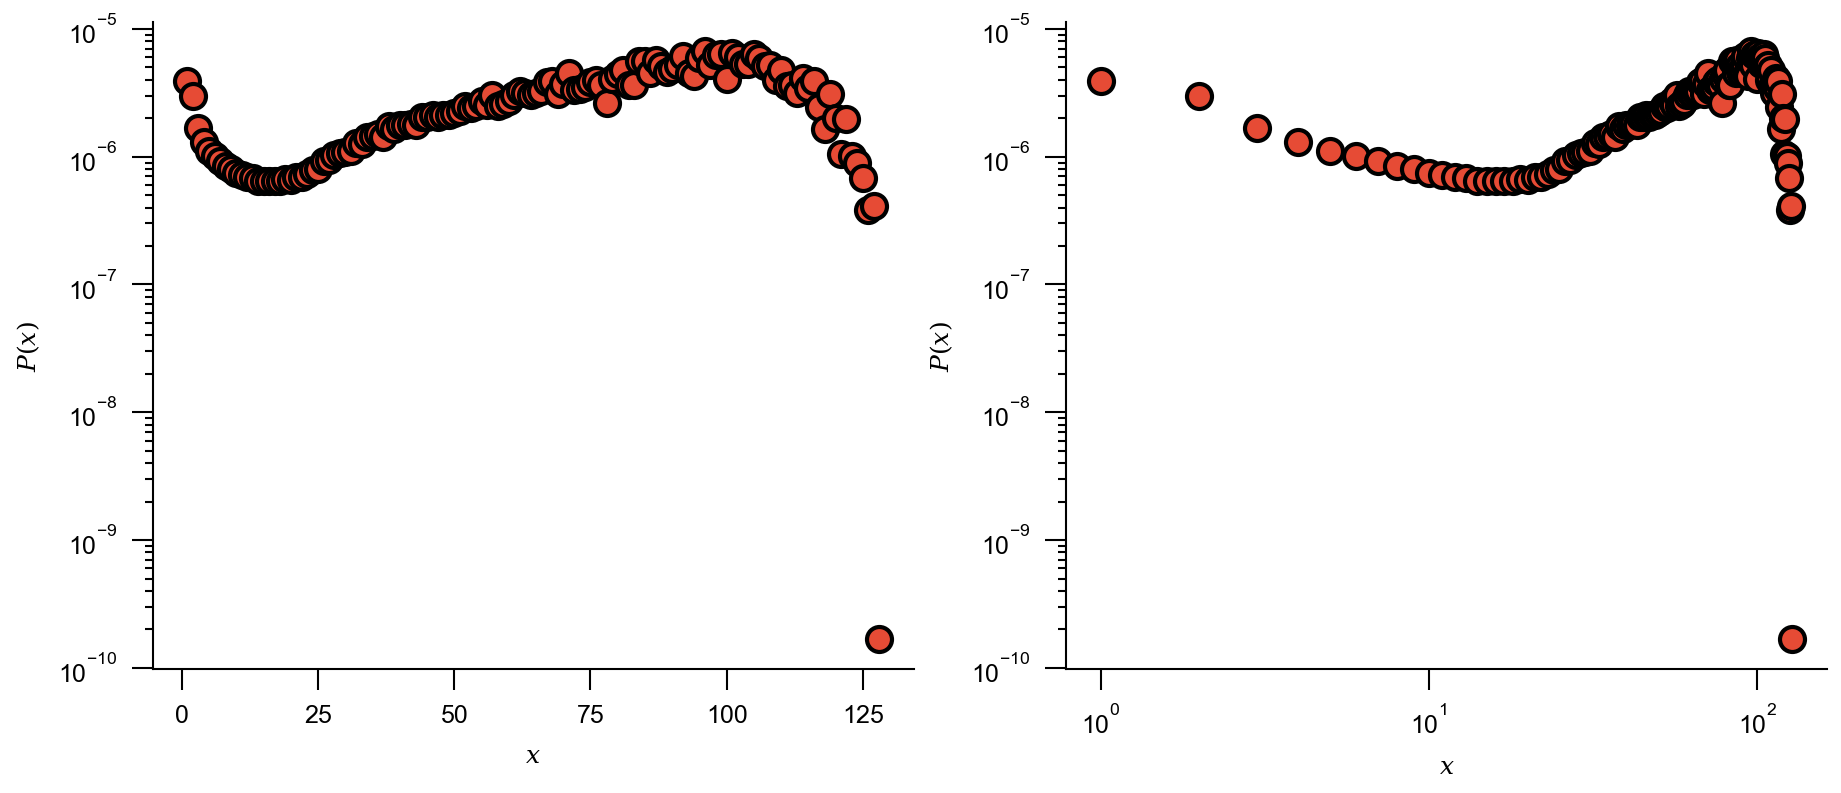

In [69]:
smin = 100
smax = 1000
test_histo = data[:, smin:smax]
sum_test = np.sum(test_histo, axis = 1)
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    ax1.scatter(np.arange(1, L1+1), sum_test/nb_ava)
    ax2.scatter(np.arange(1, L1+1), sum_test/nb_ava)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
plt.show()

### 1000<s<10000

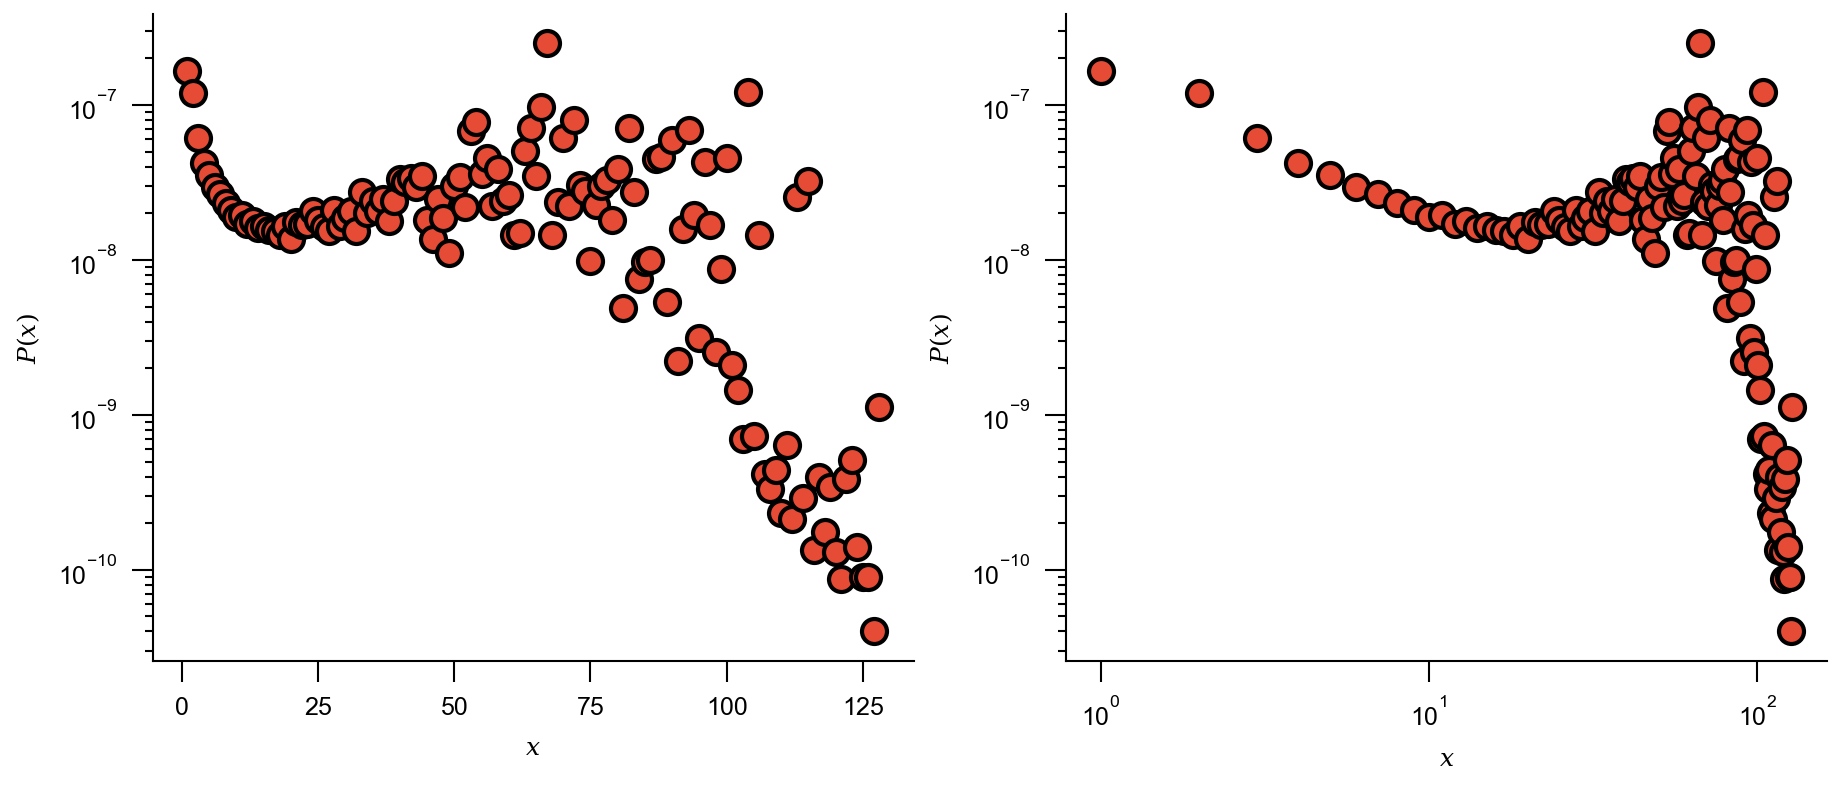

In [70]:
smin = 1000
smax = 10000
test_histo = data[:, smin:smax]
sum_test = np.sum(test_histo, axis = 1)
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    ax1.scatter(np.arange(1, L1+1), sum_test/nb_ava)
    ax2.scatter(np.arange(1, L1+1), sum_test/nb_ava)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
plt.show()

#   As function of the dissipation

##  s>2

/tmp/ipykernel_2420632/457584497.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_2420632/457584497.py:25: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava, c = colors[i], s = 20, label = nu)
/tmp/ipykernel_2420632/457584497.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with

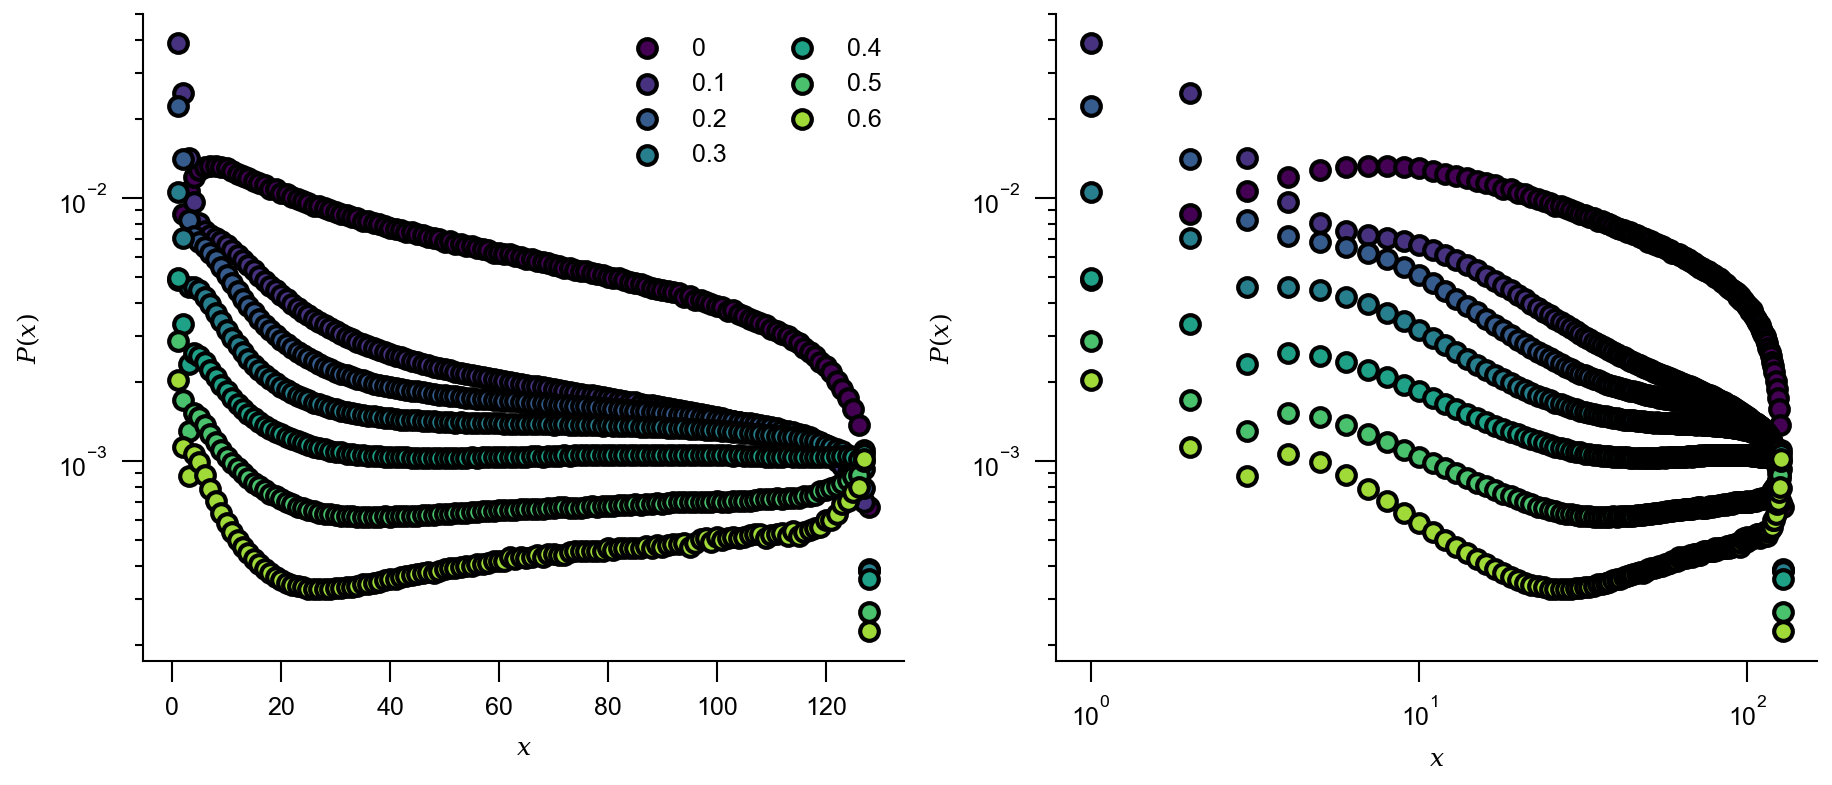

In [18]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp3n{}".format(i) for i in range(1,8)]

NCURVES = len(Tfolderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    for i, folder in enumerate(Tfolderpath):
        params = read_parameters(folder)
        L1 = params[0]
        L2 = params[1]
        nu = params[2]
        data = np.loadtxt("{}/stat_pos_histosize.txt".format(folder), comments = "#").T

        nb_ava = np.sum(data)

        smin = 2
        smax = int(len(data[0])/5)
        sup2_histo = data[:, smin:smax]

        sum_sup2_ava = np.sum(sup2_histo, axis = 1)


        ax1.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava, c = colors[i], s = 20, label = nu)
        ax2.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava, c = colors[i], s = 20)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
        
    ax1.legend(ncols = 2)
    plt.show()

##  s>1000

/tmp/ipykernel_2420632/2909172131.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_2420632/2909172131.py:25: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava, c = colors[i], s = 20, label = nu)
/tmp/ipykernel_2420632/2909172131.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches w

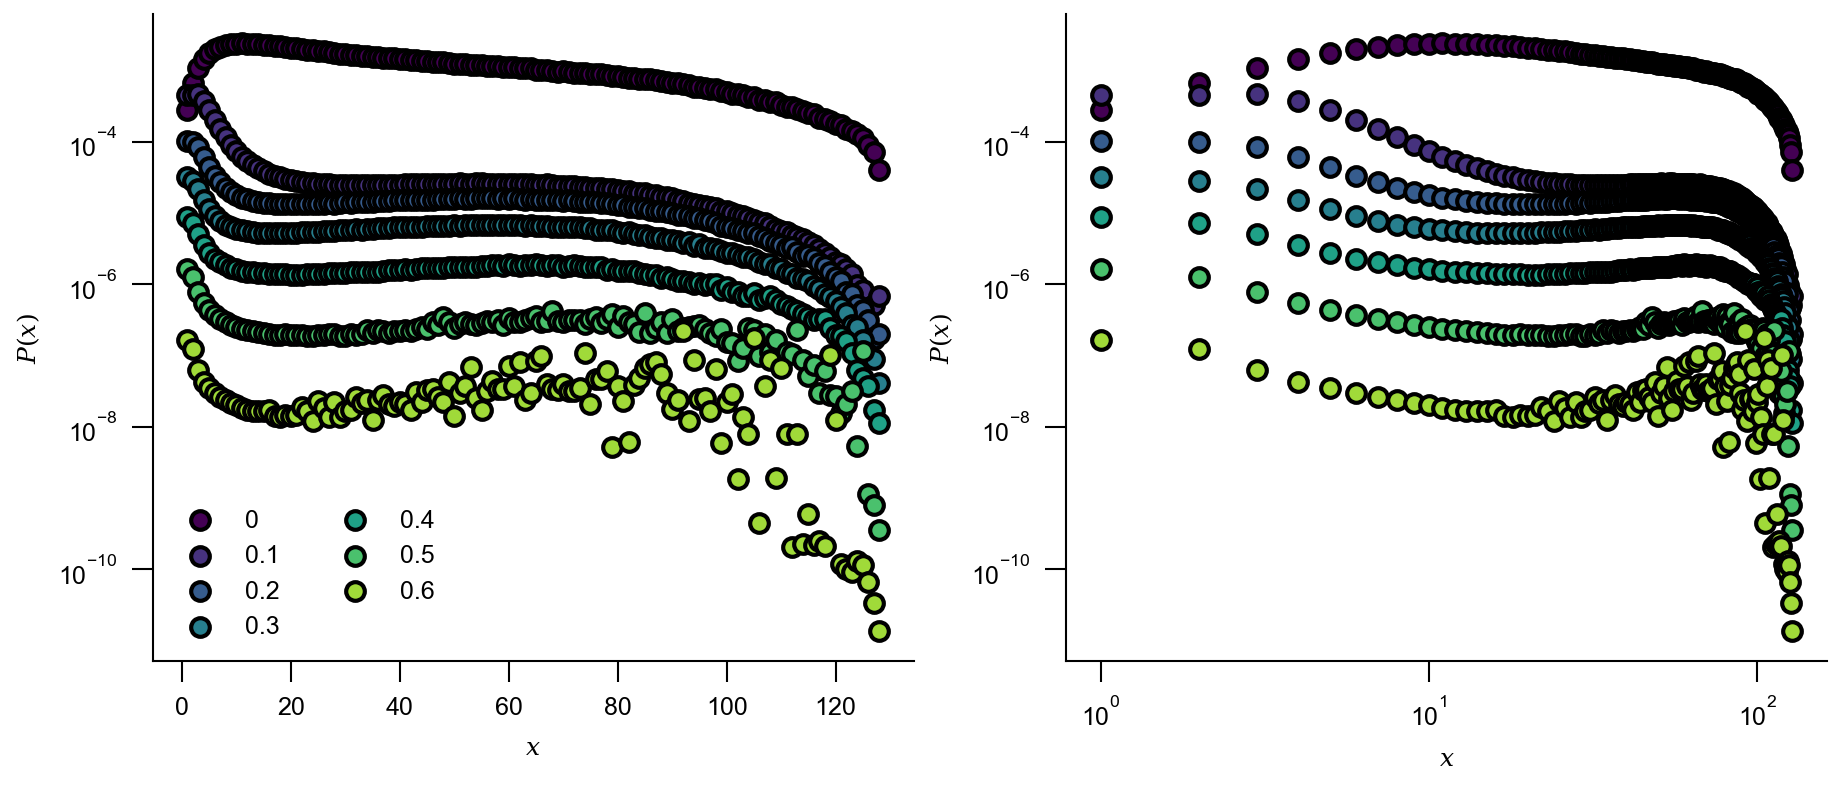

In [17]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp3n{}".format(i) for i in range(1,8)]

NCURVES = len(Tfolderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    for i, folder in enumerate(Tfolderpath):
        params = read_parameters(folder)
        L1 = params[0]
        L2 = params[1]
        nu = params[2]
        data = np.loadtxt("{}/stat_pos_histosize.txt".format(folder), comments = "#").T

        nb_ava = np.sum(data)

        smin = 1000
        smax = int(len(data[0]))
        sup2_histo = data[:, smin:smax]

        sum_sup2_ava = np.sum(sup2_histo, axis = 1)


        ax1.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava, c = colors[i], s = 20, label = nu)
        ax2.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava, c = colors[i], s = 20)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
    
    ax1.legend(ncols = 2)
    plt.show()

/tmp/ipykernel_2420632/3172036004.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_2420632/3172036004.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(np.arange(1, L1 + 1), mean_s, c = colors[i], s = 20, label = nu)
/tmp/ipykernel_2420632/3172036004.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *

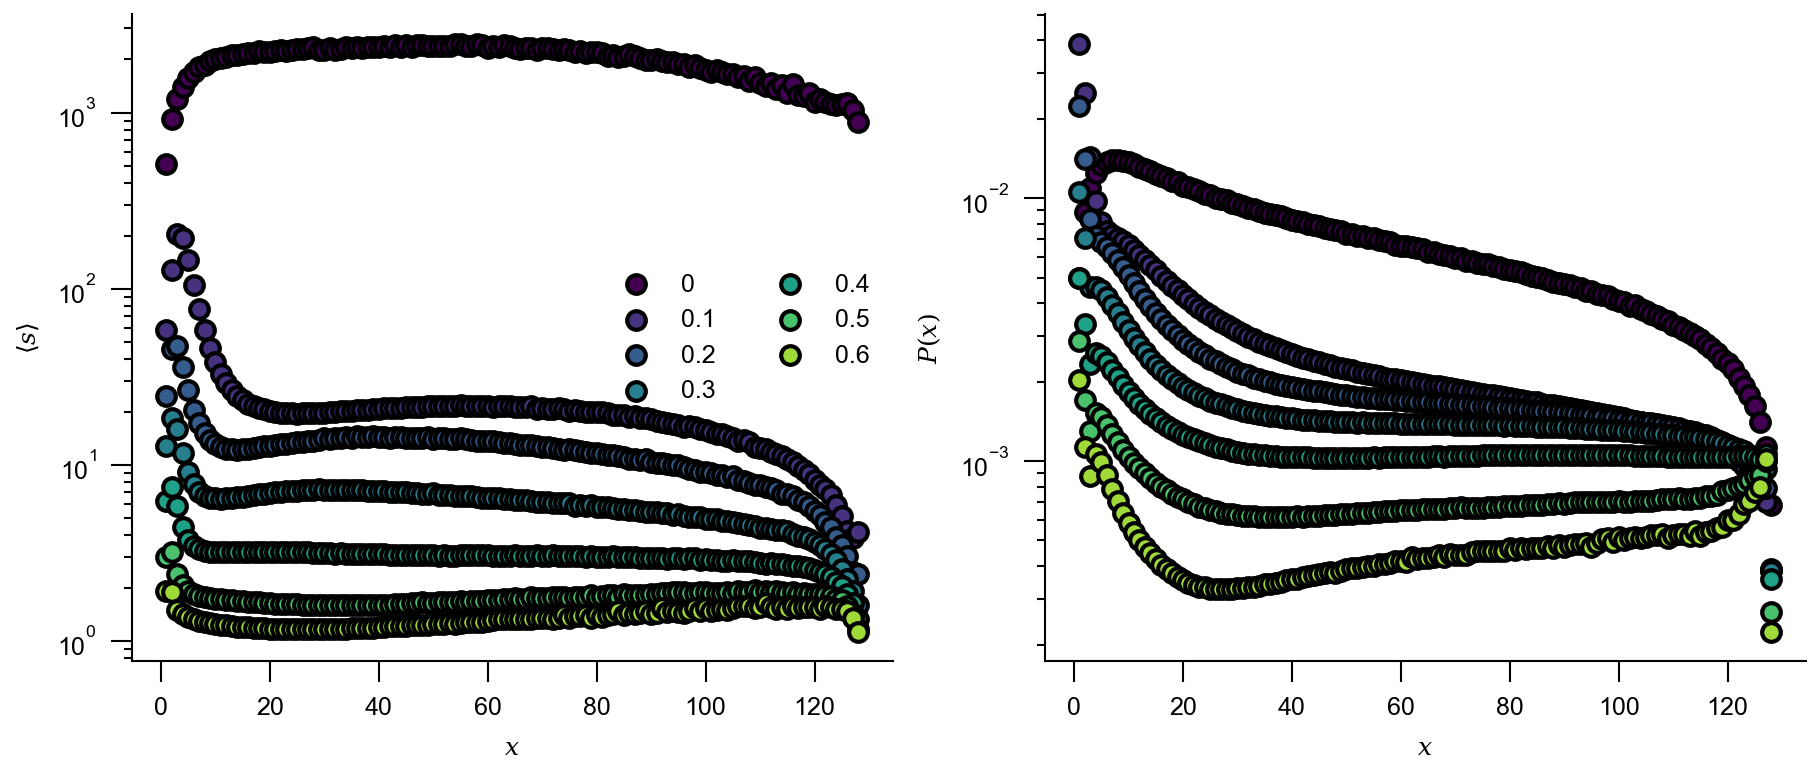

In [42]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp3n{}".format(i) for i in range(1,8)]

NCURVES = len(Tfolderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1,ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    for i, folder in enumerate(Tfolderpath):
        params = read_parameters(folder)
        L1 = params[0]
        L2 = params[1]
        nu = params[2]
        data = np.loadtxt("{}/stat_pos_histosize.txt".format(folder), comments = "#").T
        s = np.arange(L1*L2+1)

        mean_nb = [np.sum(data[i,2:])/np.sum(data) for i in range(L1)]
        mean_s = [np.sum(data[i]*s)/np.sum(data[i]) for i in range(L1)]

        ax1.scatter(np.arange(1, L1 + 1), mean_s, c = colors[i], s = 20, label = nu)
        ax2.scatter(np.arange(1, L1 + 1), mean_nb, c = colors[i], s = 20, label = nu)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$\langle s \rangle$')
    ax1.set_yscale('log')
    ax1.legend(ncols = 2)
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    plt.show()

#   PERbc

In [32]:
folder = "/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp10n7"
params = read_parameters(folder)
L1 = params[0]
L2 = params[1]
nu = params[2]
data = np.loadtxt("{}/stat_pos_histosize.txt".format(folder), comments = "#").T

nb_ava = np.sum(data)
print(nb_ava)

300000000000.0


/tmp/ipykernel_98617/3040446478.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


0.9722955012683757
0.990054283364416
0.9946757965236265
0.9953467138789991
0.9907262076492013
0.9674998477906392
0.9548712859043496
0.9591252173354493
0.9762215130555119
0.9883967977676887
0.990330478200422
0.9988907630757874
0.9963177681123454
0.9990456291099808
0.99844097128052
0.9960120061127825
0.9982249809380691
0.999225247493787
0.9964628643277853
0.9988440418917958
0.9973314901916193
0.9995344426736857
0.9990586364374078
0.9983409604925818
0.9959688067154348
0.9981611367621709
0.9990133805151981
0.9959051772040175
0.9939105298791602
0.9888797324137343
0.9974501152534397
0.995554986733714
0.9982182742028406
0.9981818305629745
0.9904387357647578
0.9865261560872807
0.9946044475600206
0.9908251417290175
0.9952985213423391
0.9889844561523371
0.9918172112571414
0.9941261438409678
0.9937126262724303
0.993284907013101
0.995554422505554
0.9950053818488955
0.989735449624184
0.9904966860804478
0.991515187370857
0.9961603383243609
0.994585095203932
0.9952697636203858
0.9924200203082979
0.99

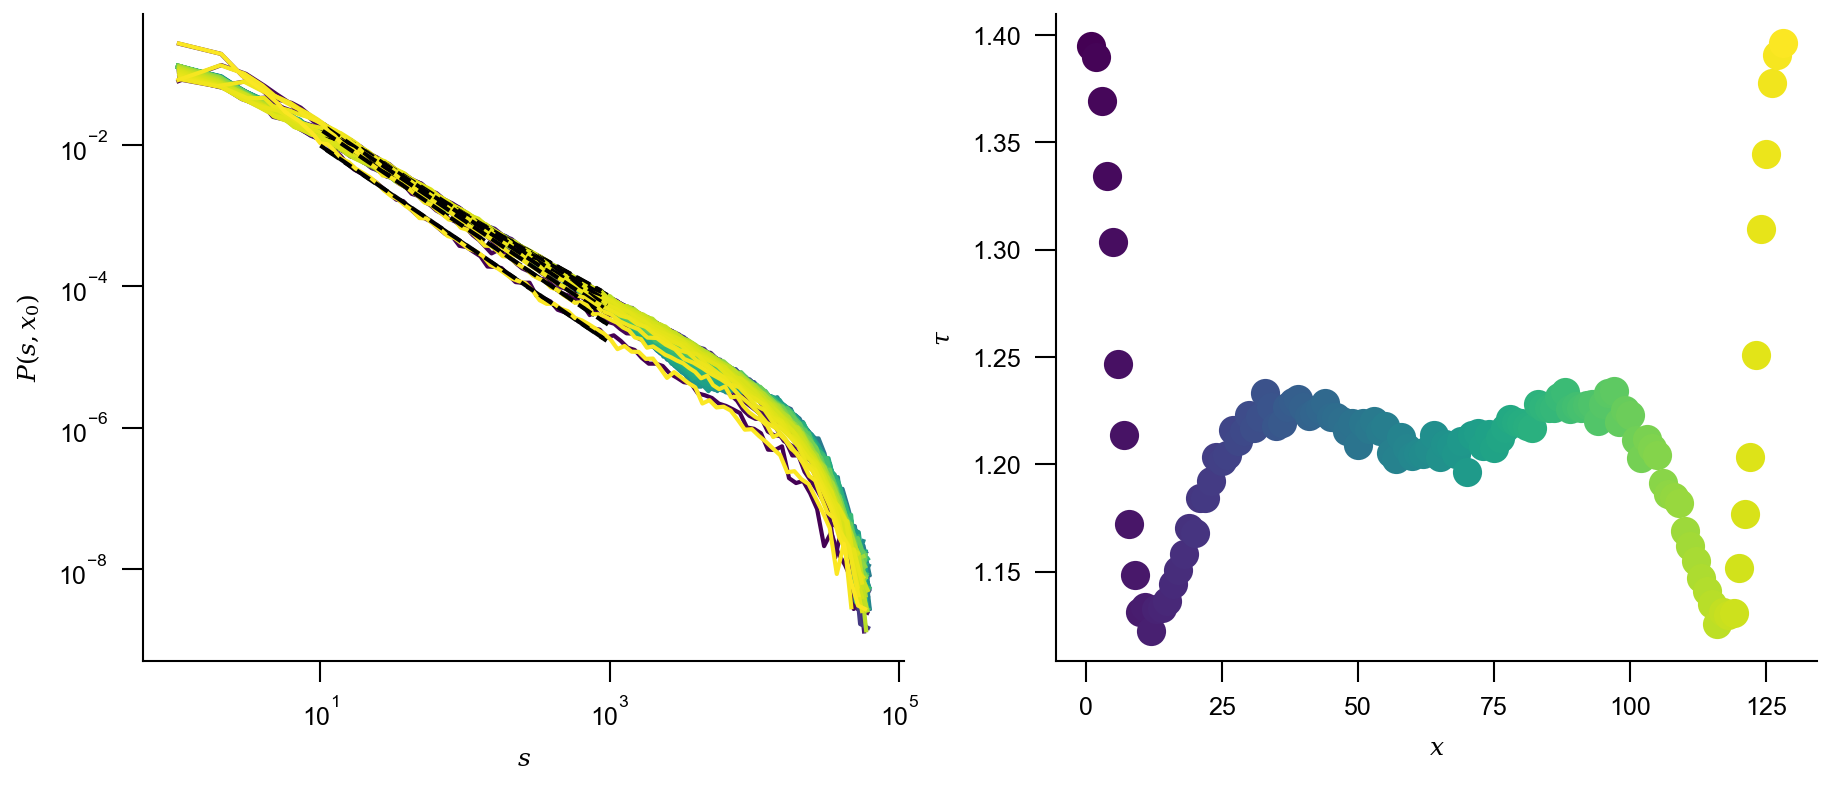

In [5]:
NCURVES = len(data)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax,ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    for i, line in enumerate(data):
        histo_s, bins_s, nonzero_s, mean_s,nbins_s = data_PDF(line)
        Txfit_s, Tyfit_s, Ttau_s, Tperr_s = PDF_fitting([histo_s], [bins_s], [10], [1100], [nu])
        if (-1<i<100000): 
            ax.plot(bins_s,histo_s, color = colors[i])
            ax.plot(Txfit_s[0],Tyfit_s[0], c = 'k', ls = '--')
        ax2.scatter(i+1, -Ttau_s[0], color = colors[i])
        
        
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$s$')
    ax.set_ylabel(r'$P(s,x_0)$')
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$\tau$')
    
plt.show()

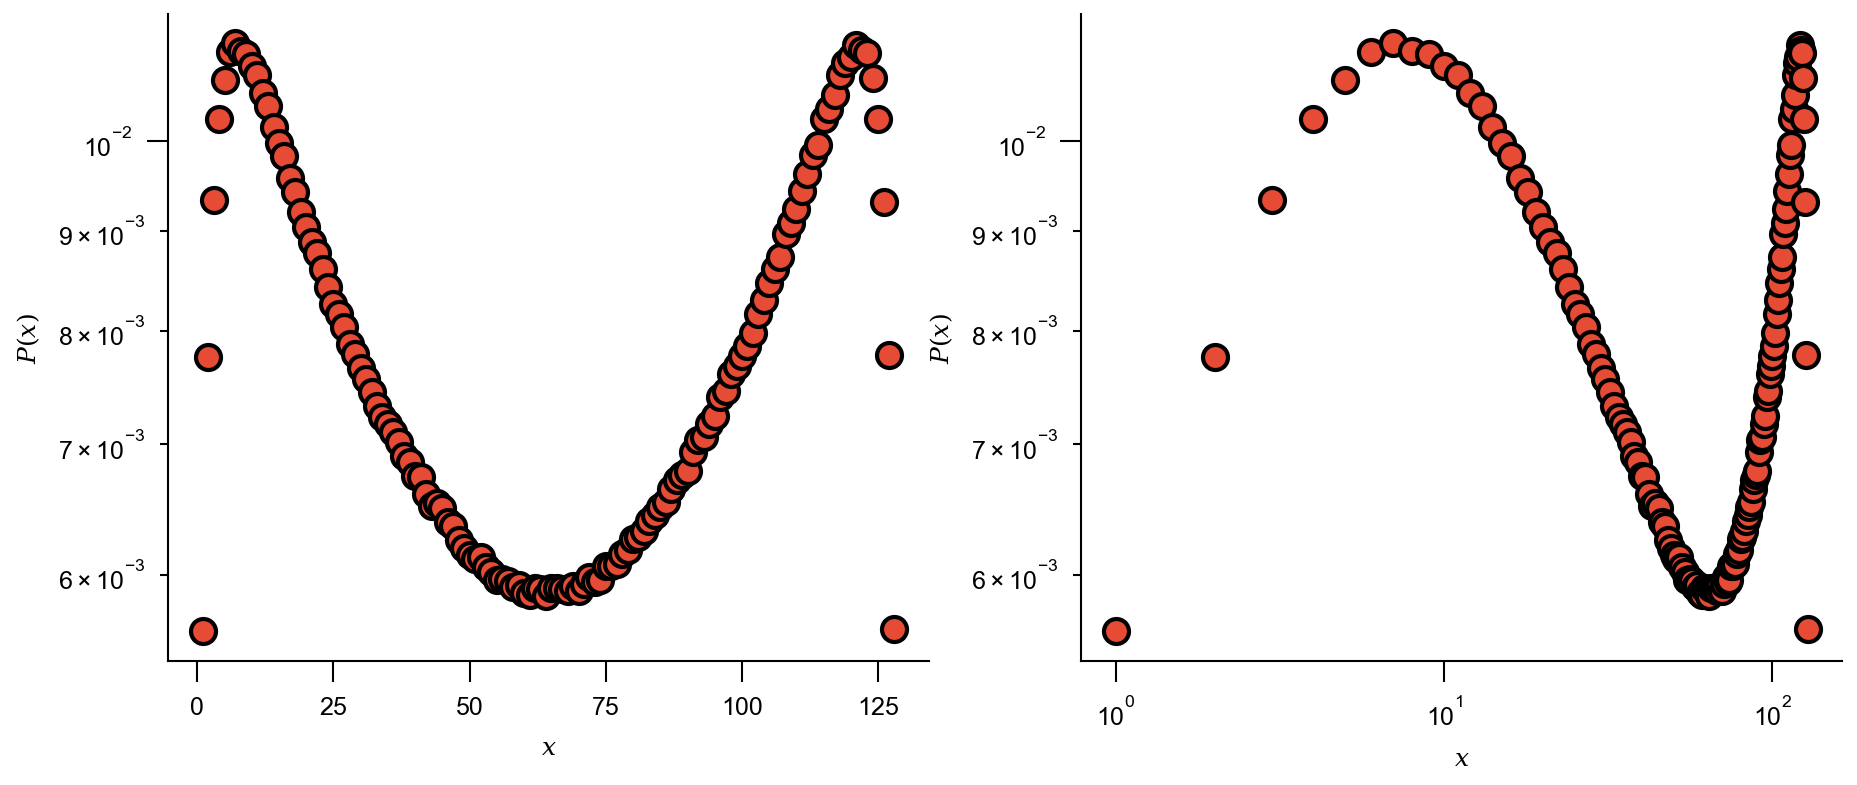

In [6]:
sum_histo = np.sum(data, axis = 1)
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    ax1.scatter(np.arange(1, L1+1), sum_histo/nb_ava)
    ax2.scatter(np.arange(1, L1+1), sum_histo/nb_ava)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
plt.show()

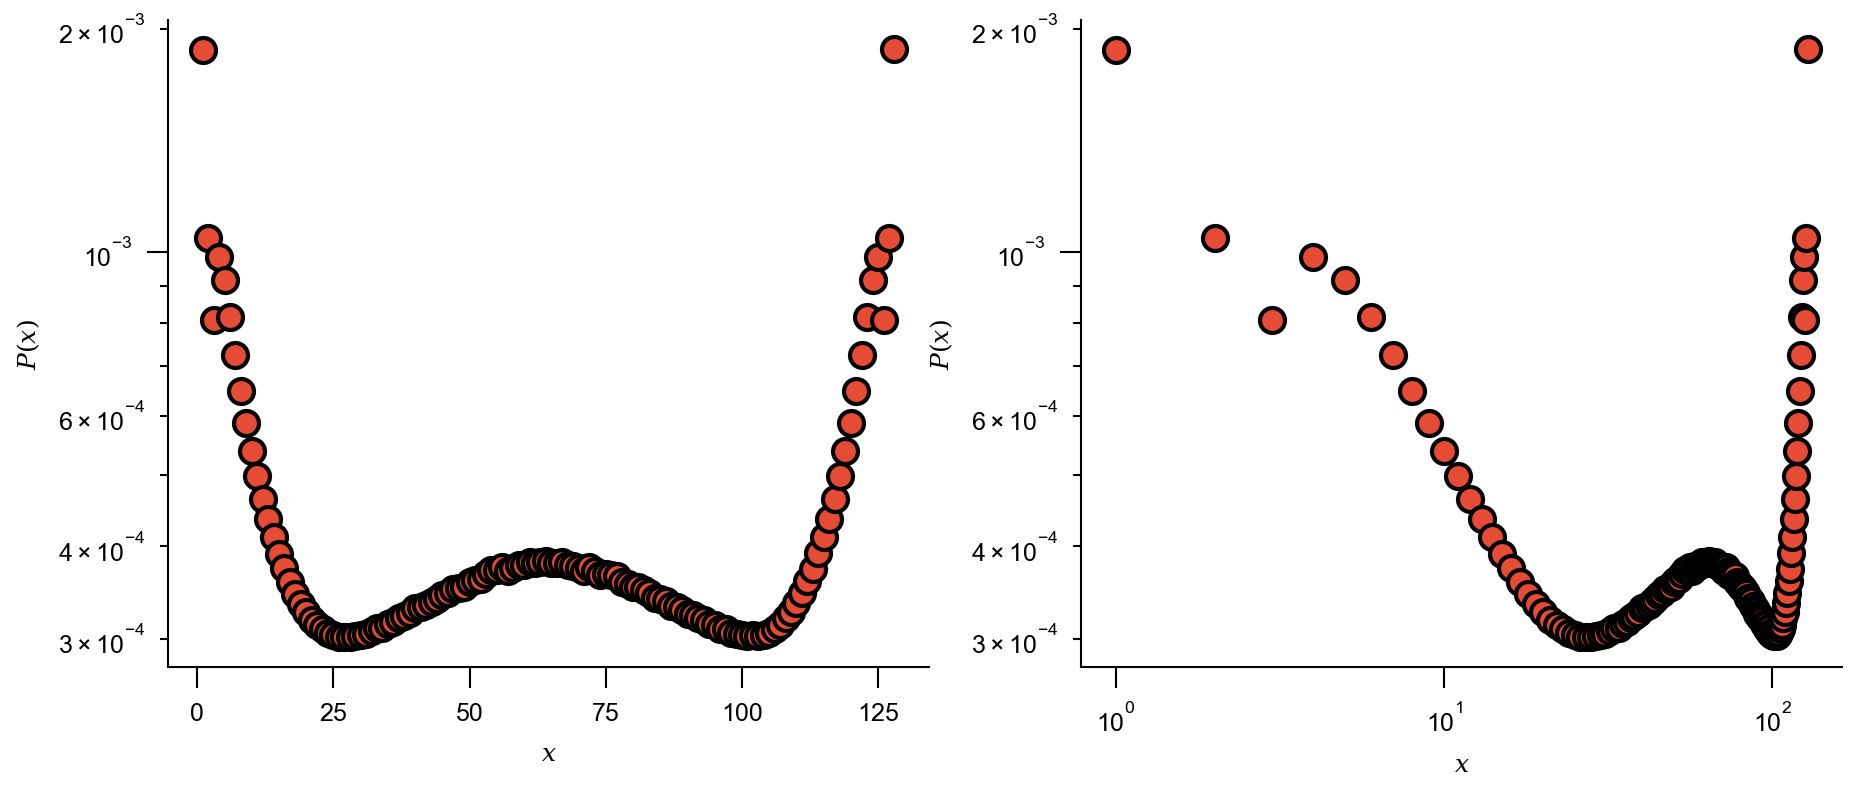

In [33]:
smin = 2
smax = int(len(data[0])/5)
sup2_histo = data[:, smin:smax]

sum_sup2_ava = np.sum(sup2_histo, axis = 1)

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    ax1.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava)
    ax2.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
plt.show()

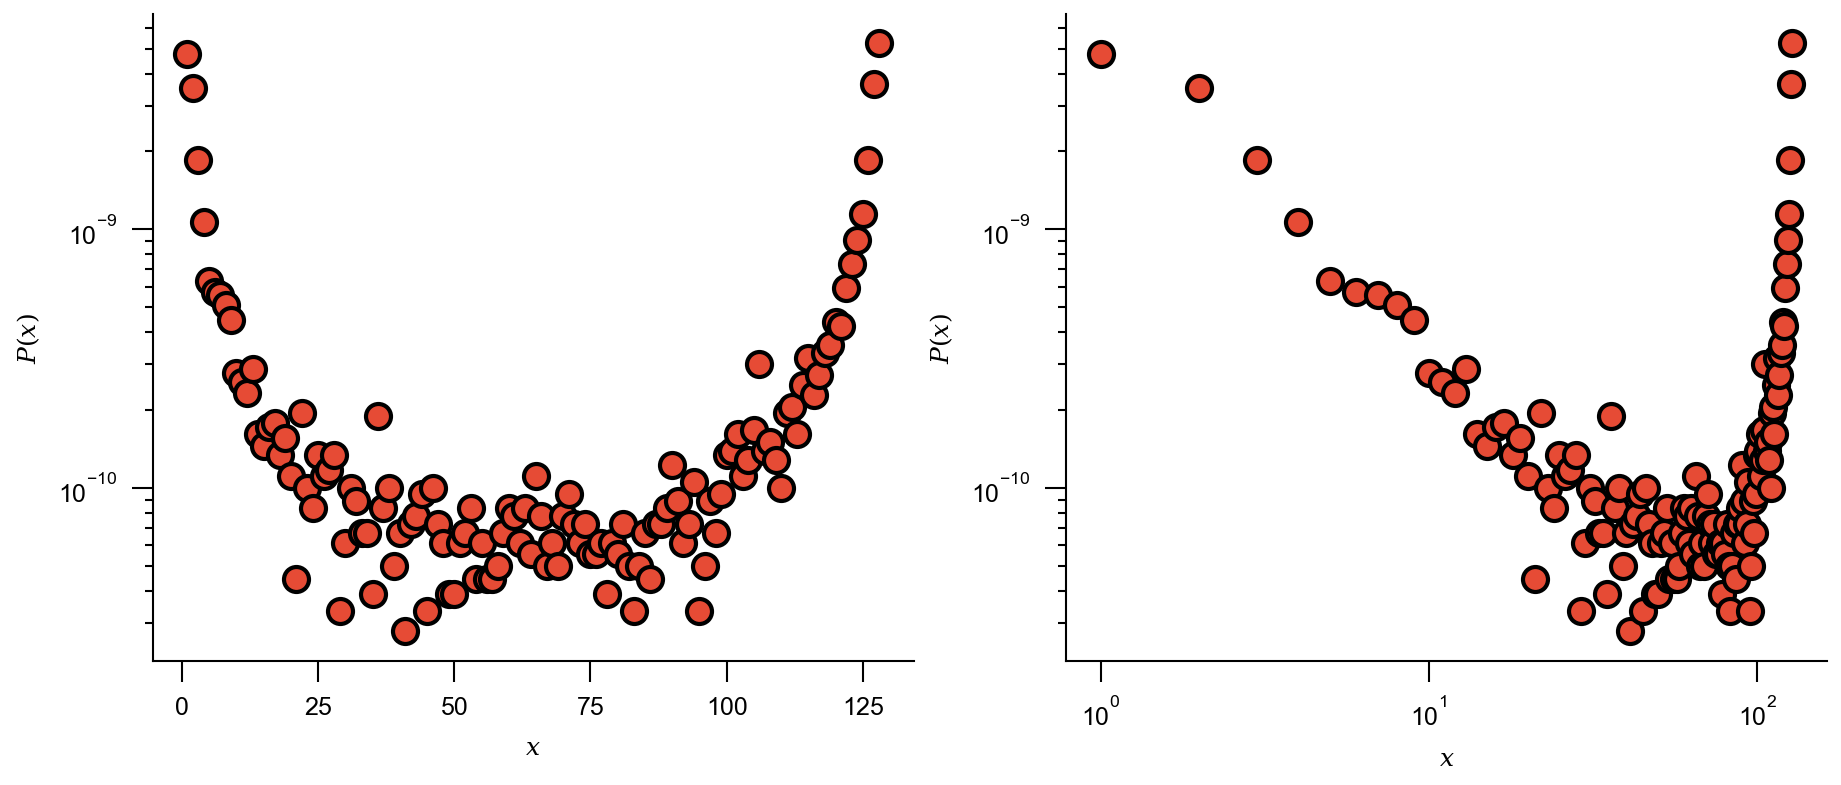

In [7]:
smin = int(len(data[0])/20)
smax = int(len(data[0]))
large_ava_histo = data[:, smin:smax]

sum_large_ava = np.sum(large_ava_histo, axis = 1)
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    ax1.scatter(np.arange(1, L1+1), sum_large_ava/nb_ava)
    ax2.scatter(np.arange(1, L1+1), sum_large_ava/nb_ava)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
plt.show()

/tmp/ipykernel_3753666/3150487555.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_3753666/3150487555.py:25: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava, c = colors[i], s = 20, label = nu)
/tmp/ipykernel_3753666/3150487555.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches w

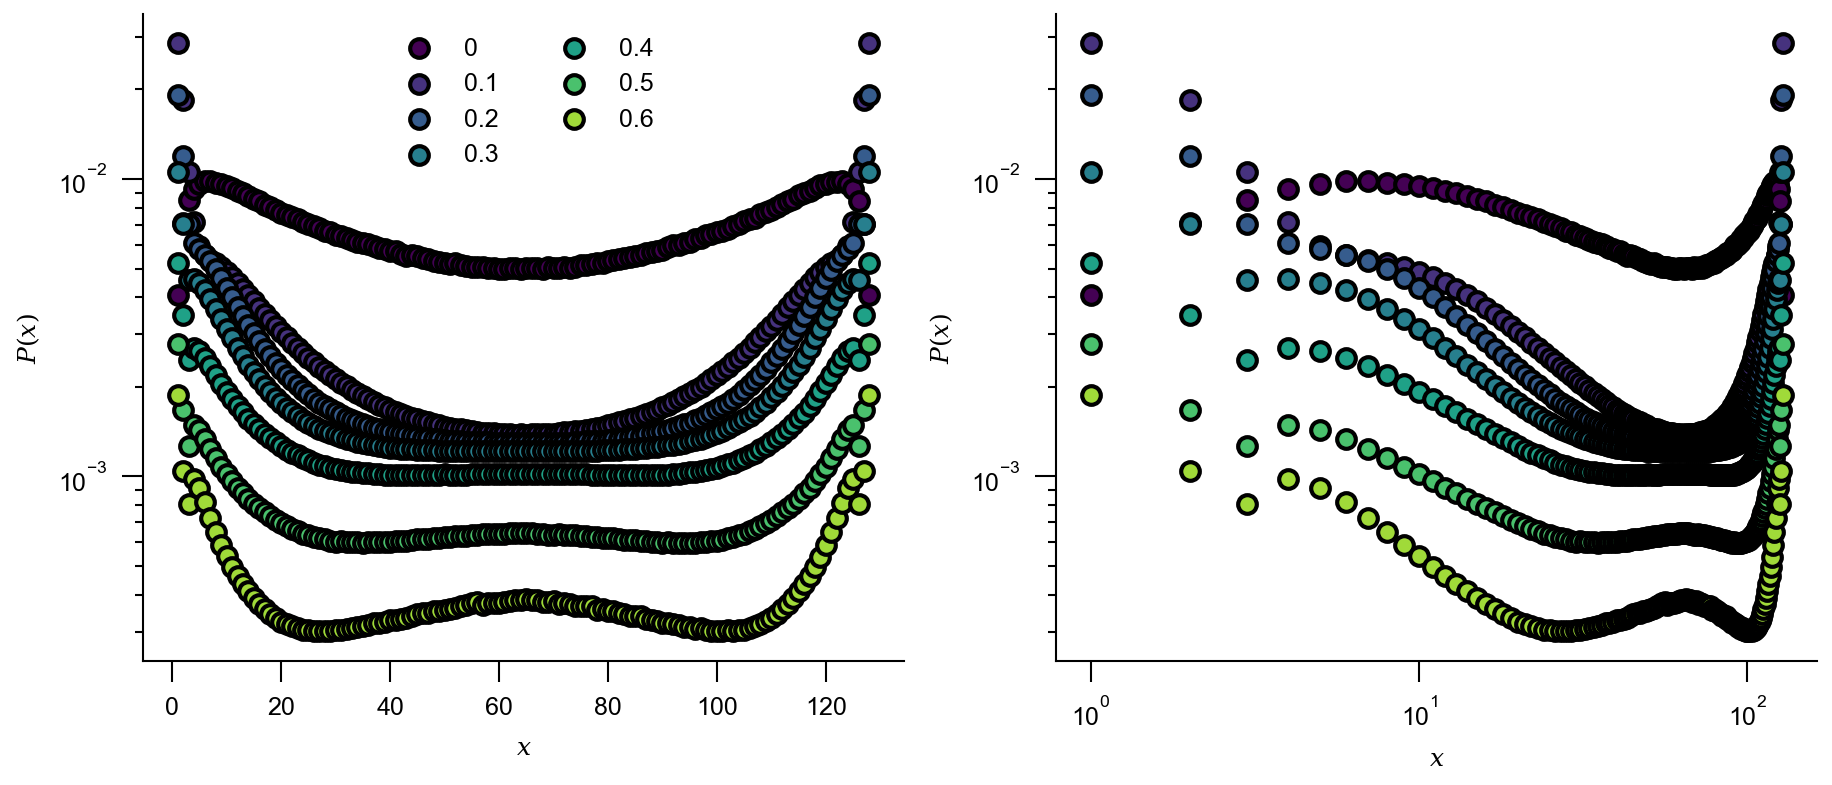

In [8]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp10n{}".format(i) for i in range(1,8)]

NCURVES = len(Tfolderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    for i, folder in enumerate(Tfolderpath):
        params = read_parameters(folder)
        L1 = params[0]
        L2 = params[1]
        nu = params[2]
        data = np.loadtxt("{}/stat_pos_histosize.txt".format(folder), comments = "#").T

        nb_ava = np.sum(data)

        smin = 2
        smax = int(len(data[0])/5)
        sup2_histo = data[:, smin:smax]

        sum_sup2_ava = np.sum(sup2_histo, axis = 1)


        ax1.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava, c = colors[i], s = 20, label = nu)
        ax2.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava, c = colors[i], s = 20)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
        
    ax1.legend(ncols = 2)
    plt.show()

/tmp/ipykernel_3753666/2488263979.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_3753666/2488263979.py:25: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava, c = colors[i], s = 20, label = nu)
/tmp/ipykernel_3753666/2488263979.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches w

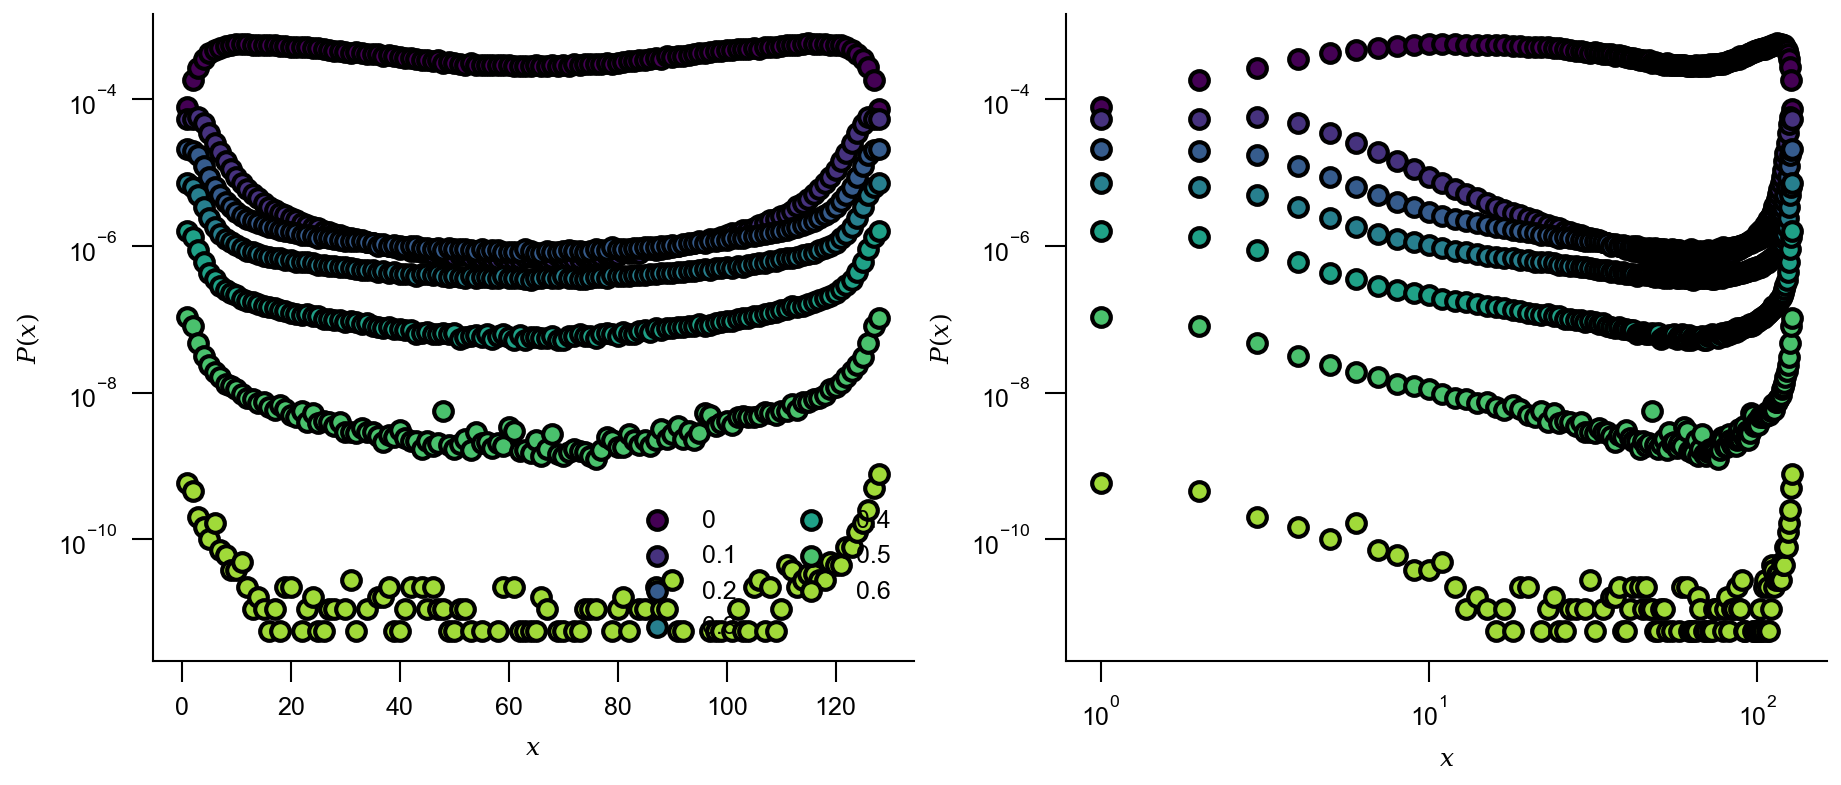

In [10]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp10n{}".format(i) for i in range(1,8)]

NCURVES = len(Tfolderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    for i, folder in enumerate(Tfolderpath):
        params = read_parameters(folder)
        L1 = params[0]
        L2 = params[1]
        nu = params[2]
        data = np.loadtxt("{}/stat_pos_histosize.txt".format(folder), comments = "#").T

        nb_ava = np.sum(data)

        smin = 5000
        smax = int(len(data[0]))
        sup2_histo = data[:, smin:smax]

        sum_sup2_ava = np.sum(sup2_histo, axis = 1)


        ax1.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava, c = colors[i], s = 20, label = nu)
        ax2.scatter(np.arange(1, L1+1), sum_sup2_ava/nb_ava, c = colors[i], s = 20)

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
    
    ax1.legend(ncols = 2)
    plt.show()

# Mass center

In [55]:
folder = "/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp13n1"
params = read_parameters(folder)
L1 = params[0]
L2 = params[1]
nu = params[2]
data = np.loadtxt("{}/stat_cm_histosize.txt".format(folder), comments = "#").T

nb_ava = np.sum(data)
print(nb_ava)

10000000.0


In [56]:
smin = 2
smax = int(len(data[0])/5)
sup2_histo = data[:, smin:smax]
sum_sup2_ava = np.sum(sup2_histo, axis = 1)

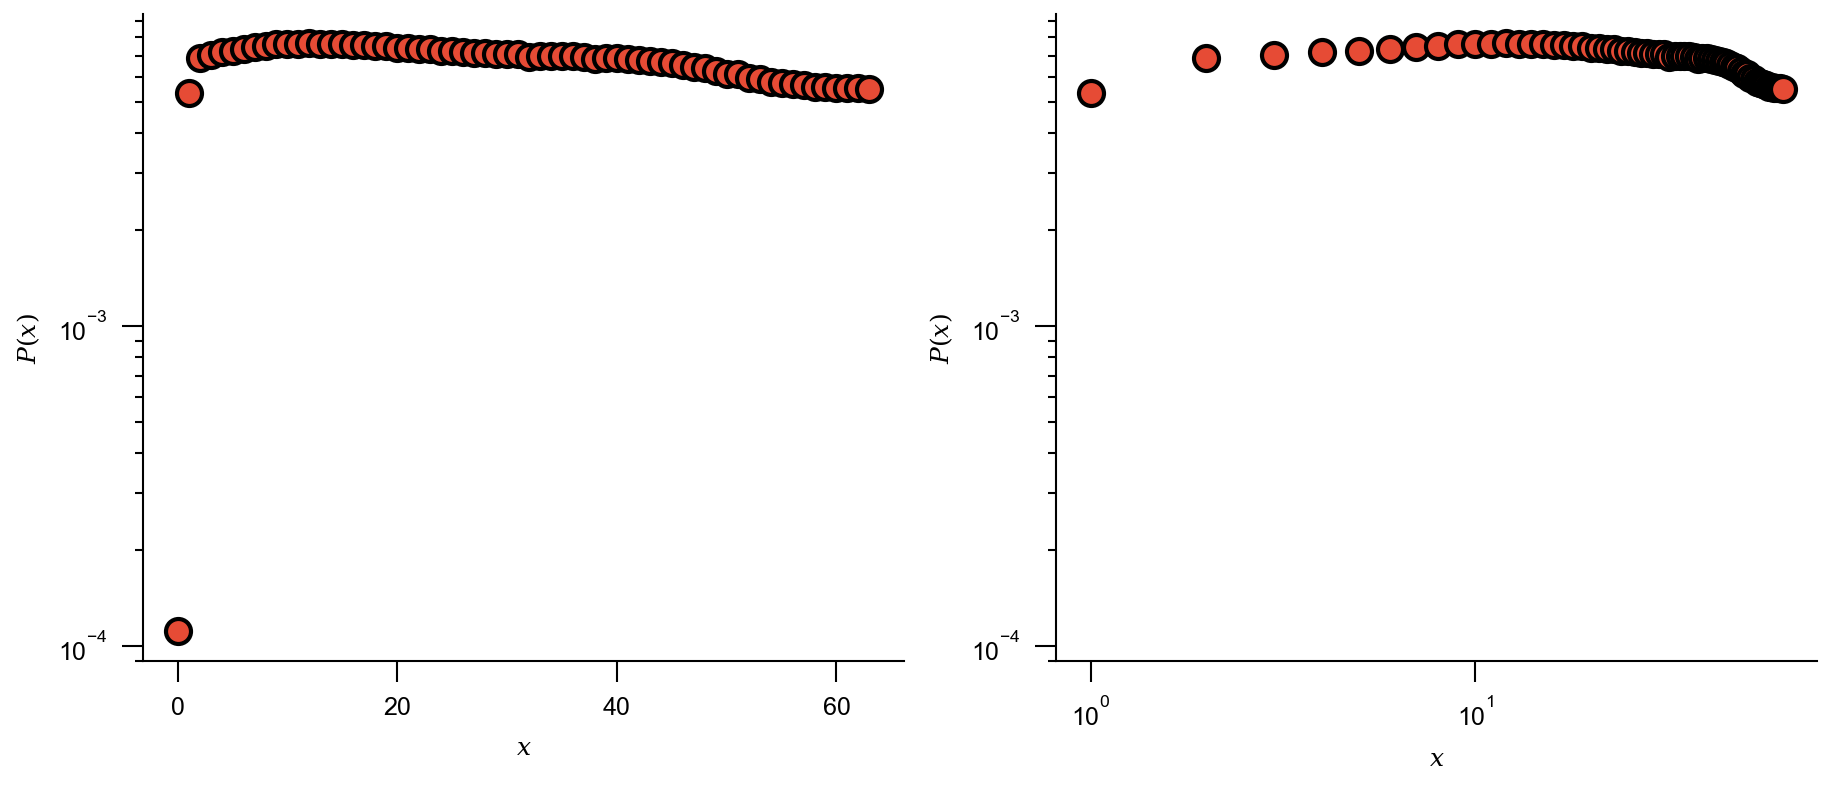

In [57]:
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    xmin = 0
    xmax = L1//2
    ax1.scatter(np.arange(xmin, xmax), (sum_sup2_ava/nb_ava)[xmin:xmax])
    ax2.scatter(np.arange(xmin, xmax), (sum_sup2_ava/nb_ava)[xmin:xmax])

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$P(x)$')
    ax1.set_yscale('log')
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(x)$')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
plt.show()

/tmp/ipykernel_1749875/1358810786.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


0.6834961296891392


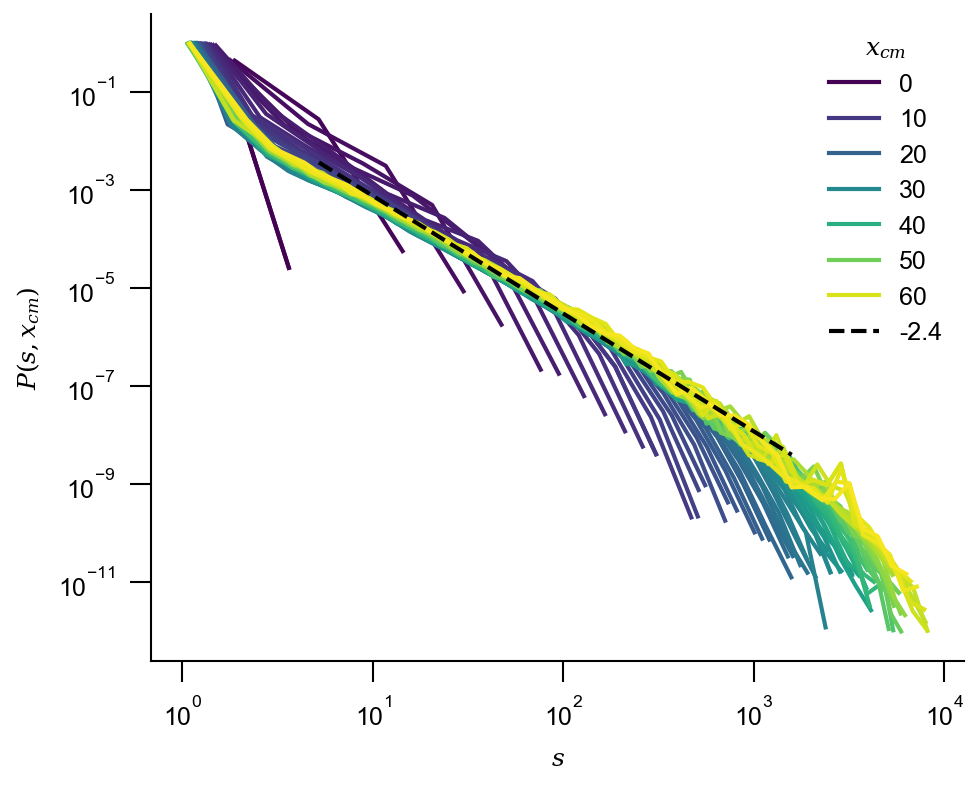

In [6]:
nb_pos = 64
NCURVES = len(data[:nb_pos])
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(1,1,figsize = (3.5, 2.8))
    for i, line in enumerate(data[:nb_pos]):
            histo_s, bins_s, nonzero_s, mean_s,nbins_s = data_PDF(line)
            if i%10 == 0:
                ax.plot(bins_s,histo_s, color = colors[i], label = i) 
            ax.plot(bins_s,histo_s, color = colors[i])
            if i == 63:
                Txfit_s, Tyfit_s, Ttau_s, Tperr_s = PDF_fitting([histo_s], [bins_s], [5], [2000], [nu])
                ax.plot(Txfit_s[0],Tyfit_s[0], c = 'k', ls = '--', label = np.round(Ttau_s[0],2))
        # ax2.scatter(i+1, -Ttau_s[0], color = colors[i])
        
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$s$')
    ax.set_ylabel(r'$P(s,x_{cm})$')
    ax.legend(title = r"$x_{cm}$")
    plt.savefig("P(s)_cm.pdf", dpi = 300)
plt.show()

/tmp/ipykernel_1749875/1339944716.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


0.9970940556293365
0.9816741234726435
0.964188980977464
0.9964692214044947
0.9862136136737474
0.886769267181735
0.9537236156077011


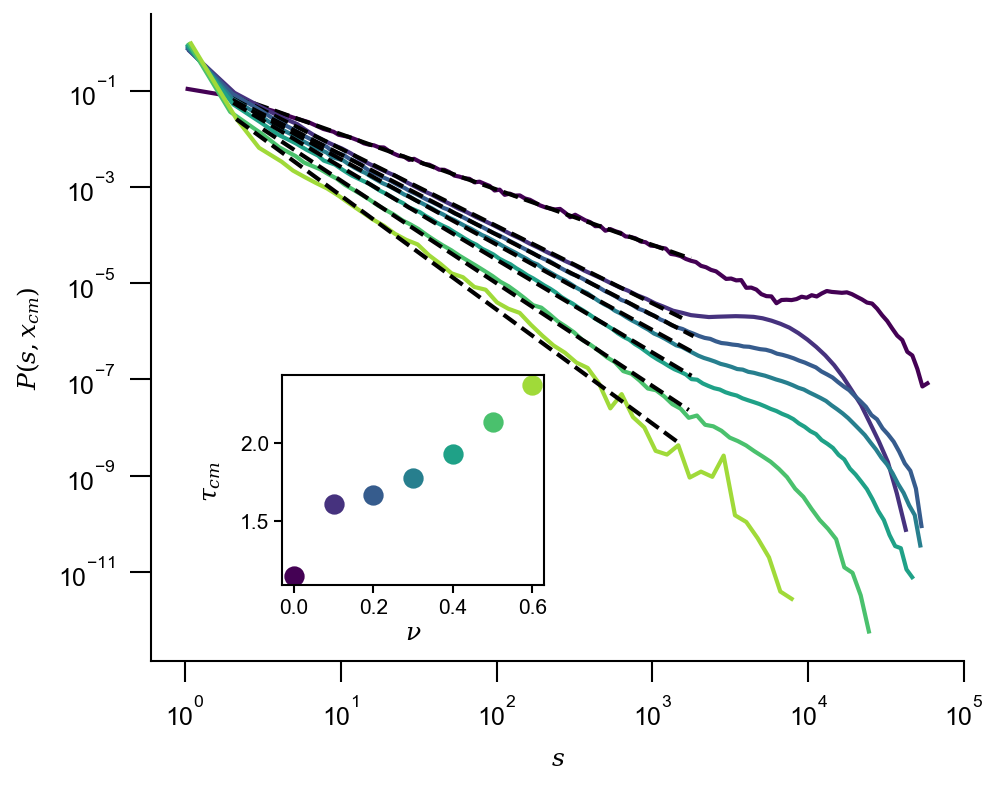

In [7]:
NCURVES = 7
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(1,1,figsize = (3.5, 2.8))
    ax2 = fig.add_axes([0.25, 0.2, 0.25, 0.25])
    for i in range(1,8):
        folder = "/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp13n{}".format(i)
        params = read_parameters(folder)
        L1 = params[0]
        L2 = params[1]
        nu = params[2]
        data = np.loadtxt("{}/stat_cm_histosize.txt".format(folder), comments = "#").T

        
        line = data[60]
        
        histo_s, bins_s, nonzero_s, mean_s,nbins_s = data_PDF(line)
        ax.plot(bins_s,histo_s, color = colors[i-1])
        
        Txfit_s, Tyfit_s, Ttau_s, Tperr_s = PDF_fitting([histo_s], [bins_s], [2], [2000], [nu])
        ax.plot(Txfit_s[0],Tyfit_s[0], c = 'k', ls = '--', label = np.round(Ttau_s[0],2))
        ax2.scatter(nu,-Ttau_s[0], color = colors[i-1], label = np.round(Ttau_s[0],2), s = 15)  
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$s$')
        ax.set_ylabel(r'$P(s,x_{cm})$')
        ax2.set_xlabel(r'$\nu$')
        ax2.set_ylabel(r'$\tau_{cm}$')
        ax2.tick_params(labelsize = 5, length = 2, pad = 1) 
        ax2.tick_params(length = 0, which = 'minor')
        ax2.spines['top'].set_visible(True)
        ax2.spines['right'].set_visible(True)
        ax2.xaxis.labelpad = 1
        # ax.legend(title = r"$x_{cm}$")
    plt.savefig("P(s_cm)_nu.pdf", dpi = 300)
    plt.show()
    
# nb_pos = 64
# NCURVES = len(data[:nb_pos])
# colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
# with plt.style.context(spstyle.get_style('nature-reviews')):
#     plt.rcParams['font.family'] = 'Arial' 
#     fig, ax = plt.subplots(1,1,figsize = (3.5, 2.8))
#     for i, line in enumerate(data[:nb_pos]):
#            s = np.arange(len(line))
#            nbava = np.sum(line)
           
#            mean = line*s/nbava
#            ax.scatter(i+1, mean, color = colors)
#     # ax.set_xscale('log')
#     # ax.set_yscale('log')
#     ax.set_xlabel(r'$x_{cm}$')
#     ax.set_ylabel(r'$\langle s \rangle$')
#     # ax.legend(title = r"$x_{cm}$")
    
# plt.show()

/tmp/ipykernel_1749875/3996802801.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


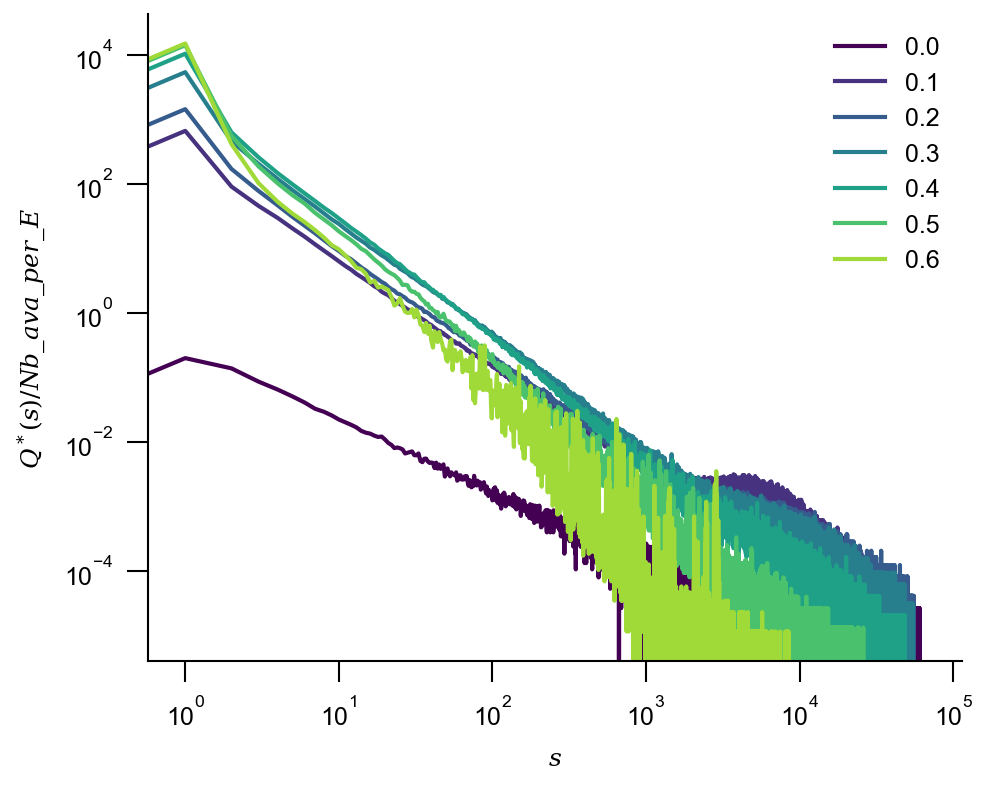

In [15]:
NCURVES = 7
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(1,1,figsize = (3.5, 2.8))
    
    for i in range(1,8):
        folder = "/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp13n{}".format(i)
        
        params = read_parameters(folder)
        L1 = params[0]
        L2 = params[1]
        nu = params[2]
        data = np.loadtxt("{}/stat_cm_histosize.txt".format(folder), comments = "#").T

        data_time = np.loadtxt("{}/time_outputB.txt".format(folder))
        dt = data_time[1,0]-data_time[0,0]
        dE = np.mean(np.diff(data_time[:,1]))
        nb_ava_per_E = dt/dE
        
        line = data[60]
        x = np.arange(len(line))
        histo_s, bins_s, nonzero_s, mean_s,nbins_s = data_PDF(line)
        ax.plot(x,line/nb_ava_per_E, color = colors[i-1], label = nu)
        
        # Txfit_s, Tyfit_s, Ttau_s, Tperr_s = PDF_fitting([histo_s], [bins_s], [5], [2000], [nu])
        # ax.plot(Txfit_s[0],Tyfit_s[0], c = 'k', ls = '--', label = np.round(Ttau_s[0],2))
        # ax2.scatter(nu,-Ttau_s[0], color = colors[i-1], label = np.round(Ttau_s[0],2))  
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$s$')
        ax.set_ylabel(r'$Q^*(s)/Nb\_ava\_per\_E$')
        # ax2.set_xlabel(r'$\nu$')
        # ax2.set_ylabel(r'$\tau_{cm}$')
        # ax.legend(title = r"$x_{cm}$")
        ax.legend()
    plt.show()